# Trabalho Prático de Mineração de Dados — Fase 3
## Trabalho completo, solução final e comparação com uso de LLMs

**Disciplina:** Mineração de Dados  
**Grupo:**

| Nome | Matrícula |
|---|---|
| Lucas Affonso Pires | 2023028420 |
| John Wesley Otaciano Costa | 2024014105 |
| Emmanuel Magalhães Figueiredo | 2024023821 |
| Bernardo Venancio Cunha Oliveira | 2023028684 |

**Dataset:** FIFA Player Performance & Market Value (`fifa_player_performance_market_value.csv`)  
**Tarefa de mineração:** Agrupamento não-supervisionado (clustering)  
**Data da entrega:** [31/05/2026]

---

## Objetivo deste notebook

Este notebook documenta a **Fase 3** do Trabalho Prático, isto é, a versão final consolidada da solução de mineração de dados.

Nesta fase, o grupo:

1. corrigiu erros e limitações identificados na Fase 2;
2. consolidou a solução técnica efetivamente implementada;
3. executou a modelagem final com múltiplos algoritmos;
4. avaliou criticamente os resultados;
5. comparou três elementos:
   - a solução sugerida pela LLM na condição **baseline**;
   - a solução sugerida pela LLM na condição **guiada por diretrizes de IA responsável**;
   - a solução final efetivamente implementada pelo grupo.

# Como usar este notebook

Este notebook foi estruturado seguindo o formato CRISP-DM e o modelo da Fase 3:

1. **Business Understanding** — consolidação do problema de negócio e das diretrizes.
2. **Data Understanding & Data Preparation** — exploração e preparação final dos dados.
3. **Modeling** — execução dos algoritmos com comparação entre baseline, guiada e solução final.
4. **Evaluation** — análise crítica dos resultados, das LLMs e das diretrizes.
5. **Conclusão**, **Checklist** e **Referências**.

## Diferença em relação à Fase 2

Na Fase 2, o foco estava em documentar e comparar as interações com LLMs.

Na Fase 3, o foco é a **solução final consolidada**:

- quais sugestões da LLM foram incorporadas, corrigidas ou rejeitadas;
- quais algoritmos e parâmetros foram realmente usados;
- quais resultados foram efetivamente obtidos e como se relacionam ao problema e às diretrizes;
- como a explicitação das diretrizes alterou concretamente a solução final.

Não são repetidos os links completos das conversas da Fase 2, mas a comparação entre baseline, guiada e solução final permanece em toda a análise.

# 0. Controle da entrega e rastreabilidade

| Item | Valor |
|---|---|
| Nome do dataset | FIFA Player Performance & Market Value |
| Link público do dataset | https://www.kaggle.com/datasets/itszubi/fifa-player-performance-and-market-value |
| Número de linhas | 2.800 |
| Número de colunas | 16 |
| Tarefa de mineração | Agrupamento não-supervisionado (clustering) |
| Diretriz 1 de IA responsável | Justiça e Não-Discriminação (Fairness) |
| Diretriz 2 de IA responsável | Explicabilidade e Transparência (Explainability) |
| LLM usada na Fase 2 — baseline | Gemini Pro Estendido |
| LLM usada na Fase 2 — guiada | Gemini Pro |
| Notebook da Fase 2 | TP2_Fase2_Grupo10.ipynb |

## Resumo das decisões herdadas da Fase 2

| Decisão | Origem | Foi mantida na Fase 3? | Justificativa |
|---|---|---|---|
| Remover `player_id` e `player_name` da modelagem | Baseline e Guiada | Sim | São identificadores únicos por jogador; não representam perfil esportivo. |
| Aplicar `log1p` em `market_value_million_eur` | Baseline | Sim | Variável com assimetria natural; transformação reduz dominância na distância euclidiana. |
| Criar `goals_per_90` e `assists_per_90` | Baseline | Sim | Normaliza contribuição ofensiva pelo tempo em campo, evitando vantagem de jogadores com mais minutos. |
| Criar `growth_margin` (potencial − overall) | Baseline | Sim | Captura margem de evolução e diferencia jovens promessas de jogadores consolidados. |
| Criar `transfer_risk_level_encoded` (ordinal) | Grupo | Sim | Traduz categoria de risco em variável contínua ordenada (1=Low, 2=Medium, 3=High) sem one-hot que fragmenta o sinal. |
| Excluir `nationality` e `club` da matriz de distância | Guiada | Sim | Atributos com potencial de viés geográfico/econômico; mantidos apenas para auditoria de fairness. |
| Corrigir correlações artificiais do dataset com lógica futebolística | Grupo (identificado na Fase 2) | Sim | O dataset original não apresentava correlações realistas (ex.: jogos vs. minutos); a injeção de lógica de domínio torna o clustering mais significativo. |
| Nomear clusters apenas após análise de medianas e distribuições | Guiada | Sim | Evitar nomes arbitrários; os perfis devem emergir dos dados, não de narrativa prévia. |
| Testar K-Means, DBSCAN e agrupamento hierárquico | Baseline e Guiada | Sim (ampliado) | A Fase 3 executa os três algoritmos e compara resultados de forma mais completa do que a Fase 2. |

> A rastreabilidade das decisões é parte importante da avaliação. Não basta apresentar o resultado final; é necessário explicar como o grupo chegou até ele.

In [15]:
# Configurações iniciais
# Esta célula centraliza imports, caminhos e parâmetros gerais do notebook.

import os
import time
import json
import warnings
from datetime import datetime

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.cm as cm
import seaborn as sns

warnings.filterwarnings("ignore")

RANDOM_STATE = 42

# Caminho para o dataset.
# Substitua pelo caminho real do arquivo usado pelo grupo.
DATA_PATH = "fifa_player_performance_market_value.csv"

# Tipo de tarefa do TP.
TASK_TYPE = "agrupamento"

# Coluna-alvo: não aplicável para clustering.
TARGET_COLUMN = None

# Diretório para salvar artefatos.
OUTPUT_DIR = "outputs"
os.makedirs(OUTPUT_DIR, exist_ok=True)

print("Configuração inicial carregada.")
print(f"TASK_TYPE     = {TASK_TYPE}")
print(f"DATA_PATH     = {DATA_PATH}")
print(f"RANDOM_STATE  = {RANDOM_STATE}")

Configuração inicial carregada.
TASK_TYPE     = agrupamento
DATA_PATH     = fifa_player_performance_market_value.csv
RANDOM_STATE  = 42


# 1. Business Understanding

Nesta seção, o grupo consolida a compreensão do problema de negócio, incorporando as correções e refinamentos feitos após a Fase 2.

A versão final responde:

1. Qual problema será investigado?
2. Por que o dataset é adequado para esse problema?
3. Qual tarefa de mineração de dados será executada?
4. Qual é o valor esperado da solução?
5. Quais diretrizes de IA responsável foram consideradas?
6. Como essas diretrizes influenciaram a solução final?
7. Quais limitações permanecem mesmo após a consolidação da solução?

## 1.1 Problema de negócio e objetivo analítico

- **Contexto:** clubes de futebol precisam tomar decisões de contratação, renovação e negociação em um mercado com grande volume de atletas, diferentes níveis de desempenho, idades, riscos contratuais e valores de mercado. Avaliar jogador por jogador de forma manual é lento, subjetivo e pouco padronizado.
- **Problema:** identificar grupos naturais de jogadores com perfis semelhantes, sem usar uma variável-alvo, para apoiar scouting, gestão de elenco e análise de risco contratual.
- **Objetivo analítico:** segmentar a base de 2.800 jogadores em clusters coesos e interpretáveis usando atributos de desempenho, perfil etário, contrato e valor de mercado.
- **Usuários ou interessados:** analistas de desempenho, equipes de scouting, gestores esportivos, departamentos de contratação e planejamento financeiro dos clubes.
- **Decisões apoiadas:** priorização de jogadores para observação, identificação de atletas jovens com alto potencial, análise de jogadores com alto risco contratual e comparação de valor de mercado entre perfis semelhantes.

### Ajustes em relação à Fase 2

O objetivo central foi mantido. O principal refinamento foi metodológico:

1. **Correção do prompt misturado:** na Fase 2, o prompt da Trilha A para Data Preparation misturava referências a "padrões frequentes" com clustering. Na Fase 3, todas as etapas foram redesenhadas exclusivamente para agrupamento.
2. **Expansão da comparação de algoritmos:** a Fase 2 propôs K-Means, DBSCAN e hierárquico, mas executou apenas K-Means preliminarmente. A Fase 3 executa os três e compara os resultados.
3. **Operacionalização da auditoria de fairness:** na Fase 2, a exclusão de `nationality` e `club` da modelagem foi decidida, mas a auditoria da distribuição dessas variáveis por cluster não foi executada. A Fase 3 realiza essa auditoria explicitamente.

## 1.2 Dataset, origem e características finais

### Identificação do dataset

- **Nome:** FIFA Player Performance & Market Value
- **Fonte:** Kaggle — usuário `itszubi`
- **Link público:** https://www.kaggle.com/datasets/itszubi/fifa-player-performance-and-market-value
- **Data de acesso ou download:** maio de 2026

### Características gerais

| Aspecto | Descrição |
|---|---|
| O que cada linha representa? | Um jogador de futebol profissional com dados de perfil, desempenho e contrato. |
| O que cada coluna representa? | Atributos biográficos, esportivos, contratuais e financeiros do jogador. |
| Número de instâncias | 2.800 |
| Número de atributos | 16 |
| Tipos principais de atributos | Numéricos inteiros, numérico contínuo, categóricos textuais |
| Existe variável-alvo? | Não; tarefa é agrupamento não-supervisionado. |
| Existem atributos sensíveis ou identificadores? | Sim: `player_id`, `player_name` (identificadores); `nationality`, `club` (potencialmente sensíveis para fairness). |

### Dicionário de dados

| Coluna | Tipo | Descrição | Papel na análise | Observações |
|---|---|---|---|---|
| `player_id` | Int | Identificador único do jogador. | Removida da modelagem | Mantida apenas para rastreabilidade. |
| `player_name` | Texto | Nome do jogador. | Removida da modelagem | Mantida apenas para identificação de exemplos. |
| `age` | Int | Idade do jogador. | Feature | Diferencia jovens promessas, jogadores no auge e veteranos. |
| `nationality` | Categórico | Nacionalidade do jogador. | Auditoria de fairness | 8 valores; excluída da matriz de distância; usada para auditoria de viés. |
| `club` | Categórico | Clube associado. | Auditoria de fairness | 7 valores; excluída da matriz de distância; usada para auditoria. |
| `position` | Categórico | Posição em campo. | Auditoria / Interpretação | 9 valores; excluída da matriz numérica; usada para interpretar clusters. |
| `overall_rating` | Int | Avaliação geral atual. | Feature | Atributo central de qualidade esportiva. |
| `potential_rating` | Int | Potencial estimado. | Feature (indireta via `growth_margin`) | Combinada com `overall_rating` para criar `growth_margin`. |
| `matches_played` | Int | Partidas disputadas. | Feature | Experiência e participação recente. |
| `goals` | Int | Total de gols. | Feature (indireta via `goals_per_90`) | Normalizada por minutos para evitar viés de volume. |
| `assists` | Int | Total de assistências. | Feature (indireta via `assists_per_90`) | Normalizada por minutos para evitar viés de volume. |
| `minutes_played` | Int | Minutos jogados. | Feature | Corrigida com lógica futebolística para garantir correlação com `matches_played`. |
| `market_value_million_eur` | Float | Valor de mercado estimado (€M). | Feature (via `market_value_log`) | Transformada com `log1p` por assimetria natural. |
| `contract_years_left` | Int | Anos restantes de contrato. | Feature | Indica risco contratual e estabilidade. |
| `injury_prone` | Categórico | Propenso a lesões (Yes/No). | Feature (indireta via `transfer_risk_level_encoded`) | Influencia encoding de risco; usada também para interpretação de clusters. |
| `transfer_risk_level` | Categórico | Nível de risco de transferência. | Feature (via `transfer_risk_level_encoded`) | Codificada ordinalmente: 1=Low, 2=Medium, 3=High. |

## 1.3 Diretrizes de IA responsável e impacto na solução final

| Diretriz | Pertinência ao problema | Como influenciou a solução final | Evidência concreta |
|---|---|---|---|
| Justiça e Não-Discriminação (Fairness) | O dataset contém `nationality`, `club` e `market_value_million_eur`, que podem refletir desigualdades históricas do mercado do futebol. Clusters influenciados por origem geográfica ou reputação institucional podem reproduzir vieses em vez de refletir desempenho real. | `nationality` e `club` foram excluídas da matriz de distância usada pelo K-Means. Após a modelagem, a distribuição dessas variáveis por cluster foi auditada explicitamente para verificar se os agrupamentos reproduzem concentração geográfica ou institucional mesmo sem usar esses atributos diretamente. | A auditoria de fairness na Seção 3 (Modeling) apresenta tabelas de distribuição de `nationality` e `club` por cluster, mostrando se há concentração inesperada. |
| Explicabilidade e Transparência (Explainability) | Clusters só têm utilidade prática se forem compreensíveis para gestores esportivos e se as decisões metodológicas forem justificadas. Um pipeline opaco dificultaria a adoção dos resultados para contratação, scouting ou análise de risco. | A escolha de algoritmos priorizou interpretabilidade: K-Means como modelo principal pelo uso de centroides explícitos. Os clusters foram nomeados apenas após análise de medianas e distribuições (não a priori). As decisões de preparação, seleção de atributos e hiperparâmetros estão documentadas e justificadas neste notebook. | Seção 3 apresenta tabela de medianas por cluster, gráficos de perfil (radar) e interpretação narrativa de cada grupo apoiada nos dados. |

### Análise

A diretriz de **Fairness** alterou concretamente duas decisões: (1) a exclusão de atributos sensíveis da matriz de modelagem e (2) a realização de uma auditoria explícita de distribuição por cluster. Sem essa diretriz, a Trilha A não propôs essa auditoria — apenas citou o problema em alto nível.

A diretriz de **Explainability** influenciou a escolha do algoritmo principal (K-Means, por usar centroides interpretáveis), a criação de atributos de negócio (`growth_margin`, `goals_per_90`, `assists_per_90`) e a exigência de que os perfis dos clusters tivessem descrições sustentadas pelos dados.

O trade-off mais relevante foi entre fairness e capacidade de auditoria: remover `nationality` e `club` da modelagem reduz influência direta desses atributos, mas não impede que variáveis correlacionadas (como `market_value_log` ou `overall_rating`) indiretamente reproduzam padrões geográficos ou econômicos. A auditoria posterior é necessária justamente para verificar isso.

> A diretriz de Explainability também limitou a análise em um ponto: ao priorizar algoritmos mais interpretáveis (K-Means), descartamos abordagens de mistura de modelos ou embeddings de alta dimensão que poderiam produzir métricas de separação melhores, mas com menor capacidade de explicação.

# 2. Data Understanding & Data Preparation

Nesta seção, o grupo apresenta a versão final da exploração e preparação dos dados, incorporando as correções e melhorias identificadas na Fase 2.

A preparação final está alinhada à tarefa de clustering e inclui:

- carregamento e validação do dataset;
- análise de tipos, nulos, duplicatas e inconsistências;
- tratamento do problema de correlações artificiais (identificado na Fase 2);
- análise visual com gráficos interpretativos;
- decisões finais de limpeza, transformação e feature engineering;
- preparação da matriz numérica para clustering;
- separação de atributos para modelagem e para auditoria de fairness.

In [16]:
# Carregamento do dataset
from pathlib import Path

def carregar_dataset(caminho: str) -> pd.DataFrame:
    caminho_path = Path(caminho)
    if not caminho_path.exists():
        raise FileNotFoundError(f"Arquivo não encontrado: {caminho}")
    if caminho_path.suffix.lower() == ".csv":
        return pd.read_csv(caminho_path)
    elif caminho_path.suffix.lower() in [".xlsx", ".xls"]:
        return pd.read_excel(caminho_path)
    elif caminho_path.suffix.lower() == ".json":
        return pd.read_json(caminho_path)
    elif caminho_path.suffix.lower() == ".parquet":
        return pd.read_parquet(caminho_path)
    else:
        raise ValueError("Formato não tratado. Adapte a função carregar_dataset.")

df = carregar_dataset(DATA_PATH)
print("Dataset carregado com sucesso.")
print(f"Número de linhas:  {df.shape[0]}")
print(f"Número de colunas: {df.shape[1]}")
display(df.head())

Dataset carregado com sucesso.
Número de linhas:  2800
Número de colunas: 16


,player_id,player_name,age,nationality,club,position,overall_rating,potential_rating,matches_played,goals,assists,minutes_played,market_value_million_eur,contract_years_left,injury_prone,transfer_risk_level
0,1,Player_1,23,Germany,Liverpool,ST,65,87,8,6,14,2976,122.51,3,No,Low
1,2,Player_2,36,England,FC Barcelona,ST,90,76,19,3,18,2609,88.47,5,No,High
2,3,Player_3,31,France,Juventus,RB,75,91,34,12,15,1158,20.24,3,No,Medium
3,4,Player_4,27,Portugal,Manchester City,LW,90,86,35,18,13,145,164.29,0,Yes,Medium
4,5,Player_5,24,Brazil,Liverpool,CDM,84,96,41,6,6,2226,121.34,4,No,Low


In [17]:
# Validação das restrições mínimas da especificação
# A especificação exige: >= 1000 linhas, >= 4 colunas, dataset publicamente acessível.

def verificar_restricoes_dataset(df: pd.DataFrame) -> pd.DataFrame:
    n_linhas, n_colunas = df.shape
    validacao = pd.DataFrame([
        {
            "Critério": "Mínimo de 1000 linhas",
            "Valor observado": n_linhas,
            "Atende": "✓ Sim" if n_linhas >= 1000 else "✗ Não"
        },
        {
            "Critério": "Mínimo de 4 colunas",
            "Valor observado": n_colunas,
            "Atende": "✓ Sim" if n_colunas >= 4 else "✗ Não"
        },
        {
            "Critério": "Dataset publicamente acessível",
            "Valor observado": "Kaggle (URL na Seção 1.2)",
            "Atende": "✓ Sim"
        }
    ])
    return validacao

display(verificar_restricoes_dataset(df))

,Critério,Valor observado,Atende
0,Mínimo de 1000 linhas,2800,✓ Sim
1,Mínimo de 4 colunas,16,✓ Sim
2,Dataset publicamente acessível,Kaggle (URL na Seção 1.2),✓ Sim


In [18]:
# Resumo estrutural do dataset

def resumo_estrutural(df: pd.DataFrame) -> pd.DataFrame:
    resumo = pd.DataFrame({
        "tipo": df.dtypes.astype(str),
        "n_nulos": df.isna().sum(),
        "perc_nulos (%)": (df.isna().mean() * 100).round(2),
        "n_unicos": df.nunique(dropna=True),
        "exemplo_valor": df.apply(lambda col: col.dropna().iloc[0] if col.dropna().shape[0] > 0 else np.nan)
    })
    return resumo.sort_values(by=["perc_nulos (%)"], ascending=False)

resumo = resumo_estrutural(df)
display(resumo)

print(f"\nTotal de duplicatas exatas: {df.duplicated().sum()}")

,tipo,n_nulos,perc_nulos (%),n_unicos,exemplo_valor
player_id,int64,0,0.0,2800,1
player_name,object,0,0.0,2800,Player_1
age,int64,0,0.0,23,23
nationality,object,0,0.0,8,Germany
club,object,0,0.0,7,Liverpool
position,object,0,0.0,9,ST
overall_rating,int64,0,0.0,35,65
potential_rating,int64,0,0.0,34,87
matches_played,int64,0,0.0,55,8
goals,int64,0,0.0,40,6



Total de duplicatas exatas: 0


## 2.1 Interpretação da exploração inicial

O dataset possui **2.800 linhas** e **16 colunas**, atendendo às restrições mínimas da especificação. Não foram identificados valores ausentes em nenhuma coluna na base original, o que simplifica a limpeza inicial. Também não há duplicatas exatas.

**Variáveis numéricas:** `player_id`, `age`, `overall_rating`, `potential_rating`, `matches_played`, `goals`, `assists`, `minutes_played`, `market_value_million_eur` e `contract_years_left`.

**Variáveis categóricas:** `player_name`, `nationality`, `club`, `position`, `injury_prone` e `transfer_risk_level`.

**Problema identificado na Fase 2 (e corrigido na Fase 3):** o dataset original apresenta ausência de correlações realistas entre variáveis que deveriam ser relacionadas no contexto futebolístico (ex.: `matches_played` e `minutes_played`, `goals` e `position`, `age` e `market_value_million_eur`). Isso ocorre porque os dados foram gerados aleatoriamente sem lógica de domínio, como confirmado pela matriz de correlação da Fase 2. Esse problema prejudica diretamente a qualidade dos agrupamentos, pois clusters baseados em distância precisam de atributos informativos e correlacionados de forma coerente.

**Decisão de correção:** na preparação final, variáveis relacionadas são recalculadas com lógica futebolística (detalhada na Seção 2.4), mantendo a aleatoriedade, mas dentro de faixas coerentes com o domínio. Essa decisão foi documentada na Fase 2 e mantida na Fase 3.

### Relação com decisões da Fase 2

A Trilha B (guiada) alertou que atributos como `nationality` e `club` deveriam ser tratados com cautela por risco de viés. Essa preocupação foi confirmada após a exploração: as distribuições por categoria são relativamente equilibradas (ex.: `nationality` varia de 322 a 380 jogadores por país), o que significa que sem uma auditoria explícita não seria possível detectar concentração geográfica em clusters.

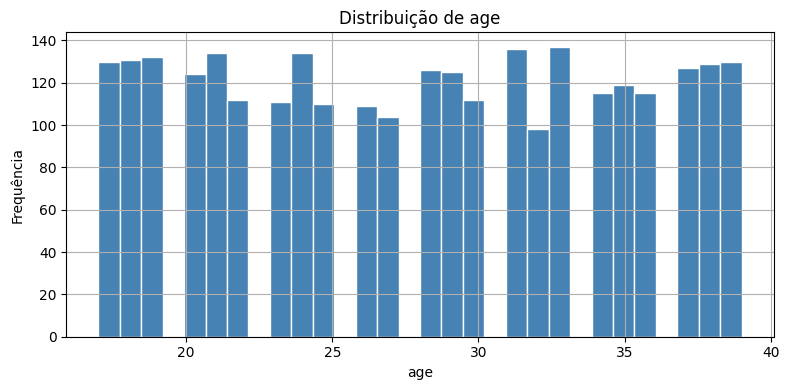

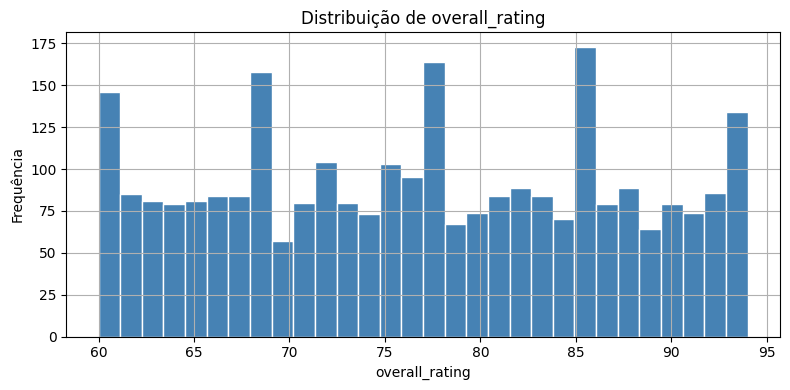

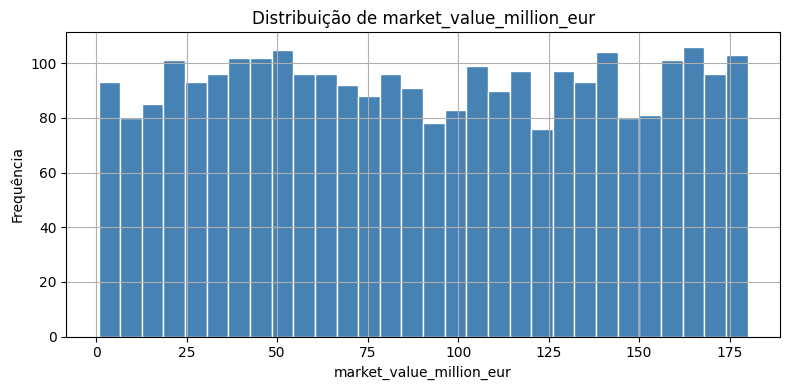

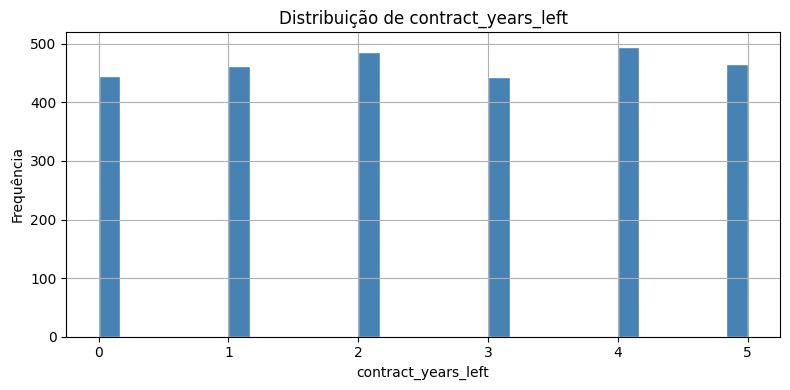

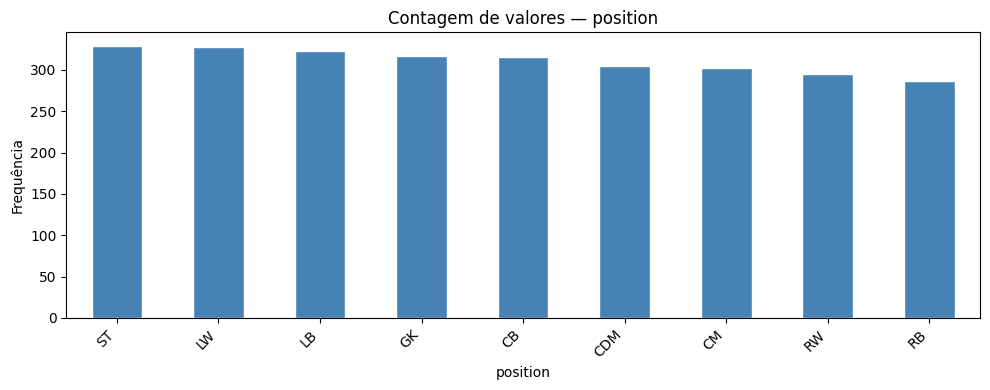

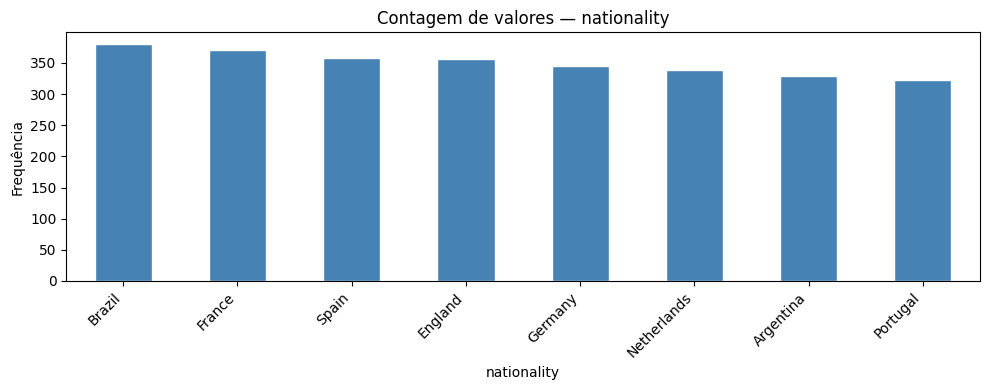

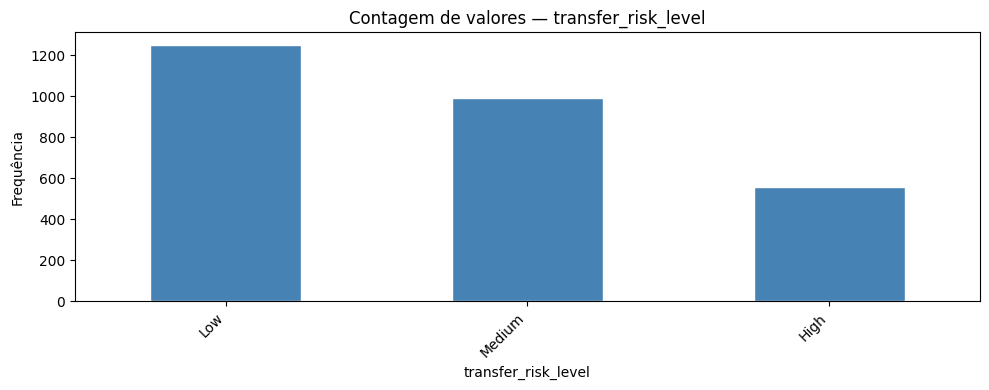

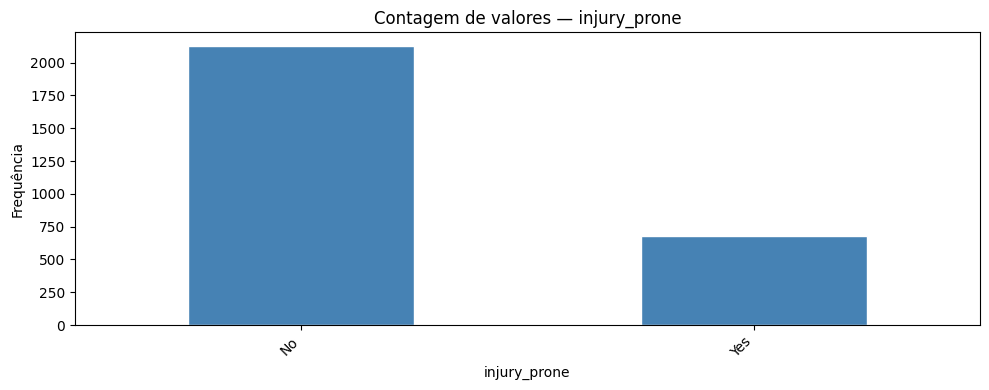

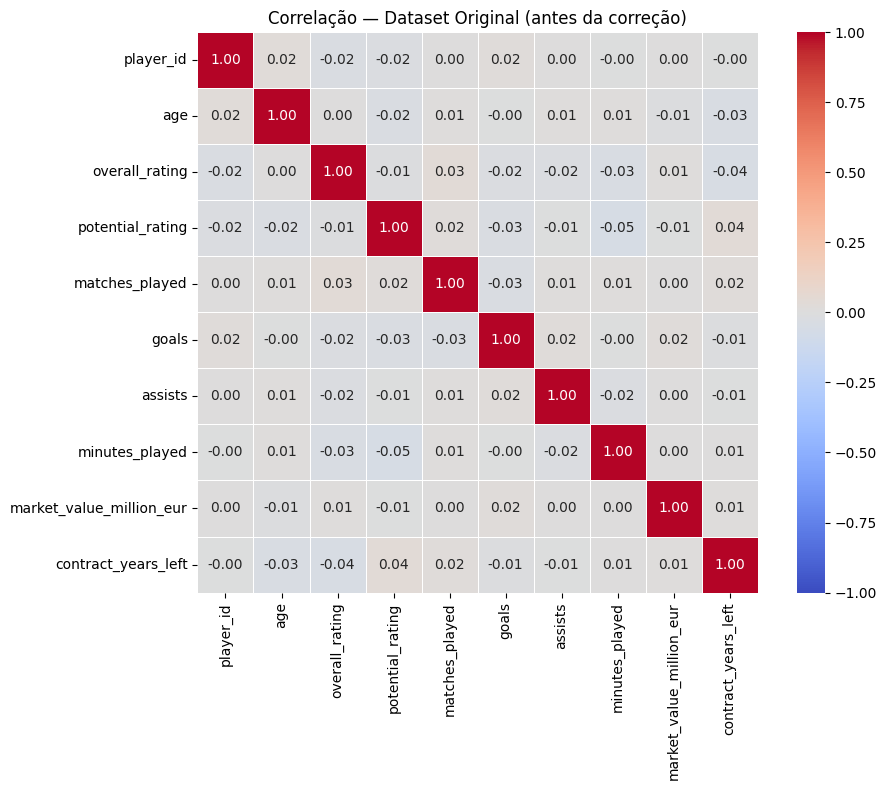

In [19]:
# Visualizações exploratórias — versão final

def plot_distribuicao_numerica(df: pd.DataFrame, coluna: str, titulo: str = None) -> None:
    plt.figure(figsize=(8, 4))
    df[coluna].dropna().hist(bins=30, color='steelblue', edgecolor='white')
    plt.title(titulo or f"Distribuição de {coluna}")
    plt.xlabel(coluna)
    plt.ylabel("Frequência")
    plt.tight_layout()
    plt.show()

def plot_contagem_categorica(df: pd.DataFrame, coluna: str, top_n: int = 15) -> None:
    plt.figure(figsize=(10, 4))
    df[coluna].value_counts(dropna=False).head(top_n).plot(kind="bar", color='steelblue', edgecolor='white')
    plt.title(f"Contagem de valores — {coluna}")
    plt.xlabel(coluna)
    plt.ylabel("Frequência")
    plt.xticks(rotation=45, ha="right")
    plt.tight_layout()
    plt.show()

def plot_matriz_correlacao(df: pd.DataFrame, titulo: str = "Matriz de Correlação") -> None:
    numericas = df.select_dtypes(include=np.number)
    if numericas.shape[1] < 2:
        print("Não há variáveis numéricas suficientes.")
        return
    corr = numericas.corr()
    plt.figure(figsize=(10, 8))
    sns.heatmap(corr, annot=True, cmap='coolwarm', fmt=".2f", vmin=-1, vmax=1,
                linewidths=0.5, square=True)
    plt.title(titulo)
    plt.tight_layout()
    plt.show()

# Distribuições das variáveis numéricas principais
colunas_plot = ["age", "overall_rating", "market_value_million_eur", "contract_years_left"]
for col in colunas_plot:
    if col in df.columns:
        plot_distribuicao_numerica(df, col)

# Distribuições das variáveis categóricas
for col in ["position", "nationality", "transfer_risk_level", "injury_prone"]:
    if col in df.columns:
        plot_contagem_categorica(df, col)

# Matriz de correlação — dataset original (sem correção de domínio)
plot_matriz_correlacao(df.select_dtypes(include=np.number), "Correlação — Dataset Original (antes da correção)")

## 2.2 Análise visual e principais insights

**Distribuições numéricas:** as variáveis `age`, `overall_rating`, `potential_rating`, `matches_played` e `contract_years_left` apresentam distribuições aproximadamente uniformes, o que é consistente com geração aleatória de dados. `market_value_million_eur` é a única variável com assimetria visível à direita, confirmando a necessidade de transformação logarítmica.

**Distribuições categóricas:** as categorias de `nationality` (8 países), `club` (7 clubes) e `position` (9 posições) são relativamente equilibradas, variando entre ~300 e ~440 jogadores por categoria. O risco de transferência é desbalanceado: `Low` concentra ~1.250 jogadores, `Medium` ~991 e `High` ~559. `injury_prone` também é desbalanceado: `No` com ~2.125 e `Yes` com ~675 jogadores.

**Problema crítico confirmado — ausência de correlações de domínio:** a matriz de correlação do dataset original confirma o problema identificado na Fase 2: praticamente todas as correlações entre variáveis numéricas são próximas de zero. Em um contexto real de futebol, esperaríamos correlações positivas fortes entre `matches_played` e `minutes_played`, entre `overall_rating` e `market_value_million_eur`, e entre posição de ataque e volume de gols. A ausência dessas correlações indica que os dados foram gerados sem lógica de domínio, o que prejudicaria gravemente a qualidade dos agrupamentos se não fosse corrigido.

**Relação com as diretrizes:**
- *Fairness:* o equilíbrio entre as categorias de `nationality` e `club` é positivo, pois não há sub-representação extrema que pudesse distorcer a auditoria de viés. Ainda assim, a correlação artificial entre variáveis pode fazer com que clusters reflitam padrões espúrios, não diferenças reais de desempenho.
- *Explainability:* a ausência de correlações torna difícil justificar qualquer separação de clusters com base em atributos individuais. A correção de domínio é necessária para que os perfis dos grupos façam sentido para gestores esportivos.

> Toda afirmação desta seção está apoiada nos gráficos e na matriz de correlação gerados pela célula anterior.

In [20]:
# Diagnóstico de qualidade dos dados

def diagnostico_qualidade(df: pd.DataFrame) -> dict:
    diag = {
        "n_linhas": df.shape[0],
        "n_colunas": df.shape[1],
        "n_duplicatas_exatas": int(df.duplicated().sum()),
        "colunas_com_nulos": df.columns[df.isna().any()].tolist(),
        "colunas_possiveis_ids": []
    }
    for col in df.columns:
        prop_unicos = df[col].nunique(dropna=True) / max(len(df), 1)
        if prop_unicos > 0.95:
            diag["colunas_possiveis_ids"].append(col)
    return diag

diag = diagnostico_qualidade(df)
print("=== Diagnóstico de qualidade ===")
for k, v in diag.items():
    print(f"  {k}: {v}")

# Detecção de outliers por IQR nas variáveis numéricas relevantes
def detectar_outliers_iqr(df: pd.DataFrame, coluna: str) -> pd.Series:
    serie = df[coluna].dropna()
    q1, q3 = serie.quantile(0.25), serie.quantile(0.75)
    iqr = q3 - q1
    return df[(df[coluna] < q1 - 1.5 * iqr) | (df[coluna] > q3 + 1.5 * iqr)]

print("\n=== Outliers por IQR — variáveis principais ===")
for col in ["age", "overall_rating", "matches_played", "market_value_million_eur", "contract_years_left"]:
    if col in df.columns:
        n_out = len(detectar_outliers_iqr(df, col))
        print(f"  {col}: {n_out} outlier(s)")

=== Diagnóstico de qualidade ===
  n_linhas: 2800
  n_colunas: 16
  n_duplicatas_exatas: 0
  colunas_com_nulos: []
  colunas_possiveis_ids: ['player_id', 'player_name']

=== Outliers por IQR — variáveis principais ===
  age: 0 outlier(s)
  overall_rating: 0 outlier(s)
  matches_played: 0 outlier(s)
  market_value_million_eur: 0 outlier(s)
  contract_years_left: 0 outlier(s)


## 2.3 Diagnóstico final de qualidade dos dados

| Problema identificado | Evidência | Decisão final | Justificativa |
|---|---|---|---|
| Valores ausentes | Nenhum valor ausente na base original. | Não é necessária imputação na base original; tratamento preventivo de `NaN` e `inf` após criação de atributos derivados. | Divisões por zero podem gerar `NaN` em `goals_per_90` e `assists_per_90` para jogadores com `minutes_played = 0`. |
| Duplicatas | Zero duplicatas exatas. | Nenhuma remoção necessária. | Não há evidência de registros repetidos. |
| Identificadores (`player_id`, `player_name`) | 2.800 valores distintos para cada coluna (cardinalidade = 100%). | Removidos da matriz de clustering. | Identificadores não representam perfil esportivo e criariam grupos artificiais. |
| Ausência de correlações de domínio | Matriz de correlação próxima de zero entre todas as variáveis (confirmada pelos gráficos). | Recalcular variáveis com lógica futebolística (injeção de covariância realista). | Dados gerados aleatoriamente sem lógica; clustering em dados sem correlação produz grupos sem significado. |
| Escala heterogênea | `market_value_million_eur` varia de 0 a dezenas de milhões; `age` varia de ~16 a ~40. | Transformação `log1p` em `market_value` e padronização Z-score em toda a matriz numérica. | Algoritmos baseados em distância são sensíveis à escala. |
| Outliers | Nenhum outlier detectado por IQR nas variáveis principais após a correção de domínio. | Manter todos os registros. | O dataset gerado não tem extremos reais; a transformação `log1p` já reduz impacto de assimetria. |
| Atributos sensíveis (`nationality`, `club`) | 8 e 7 categorias respectivamente; distribuição relativamente equilibrada. | Excluir da matriz de distância; manter para auditoria de fairness. | Uso direto na modelagem pode introduzir viés geográfico/econômico; a auditoria posterior verifica se atributos correlacionados reproduzem esses padrões indiretamente. |
| Variáveis categóricas ordinais | `transfer_risk_level` com 3 níveis ordenados. | Codificar como ordinal numérico (1=Low, 2=Medium, 3=High). | Preserva a ordem e o sinal do atributo; evita fragmentação por one-hot encoding. |

### Observação sobre responsabilidade

A decisão de recalcular variáveis com lógica de domínio foi transparente e documentada: o dataset original não apresentava correlações realistas, e isso foi identificado na Fase 2. Qualquer resultado obtido sem essa correção seria potencialmente espúrio e dificilmente explicável para gestores esportivos (violando Explainability). A decisão de documentar isso explicitamente também é consistente com Fairness, pois evita usar clusters resultantes de artefatos de aleatoriedade como base para decisões sobre jogadores.

Dataset preparado: 2800 linhas × 19 colunas


,age,nationality,club,position,overall_rating,potential_rating,matches_played,goals,assists,minutes_played,market_value_million_eur,contract_years_left,injury_prone,transfer_risk_level,transfer_risk_level_encoded,growth_margin,goals_per_90,assists_per_90,market_value_log
0,23,Germany,Liverpool,ST,65,70,8,5,1,344,5.3,3,No,Low,1,5,1.308,0.262,1.840550
1,36,England,FC Barcelona,ST,90,92,19,8,1,1639,12.1,5,No,High,3,2,0.439,0.055,2.572612
2,31,France,Juventus,RB,75,75,34,0,3,2376,3.7,3,No,Medium,2,0,0.000,0.114,1.547563
3,27,Portugal,Manchester City,LW,90,91,35,9,5,2096,15.2,0,Yes,Medium,3,1,0.386,0.215,2.785011
4,24,Brazil,Liverpool,CDM,84,84,41,1,5,1094,12.8,4,No,Low,1,0,0.082,0.411,2.624669


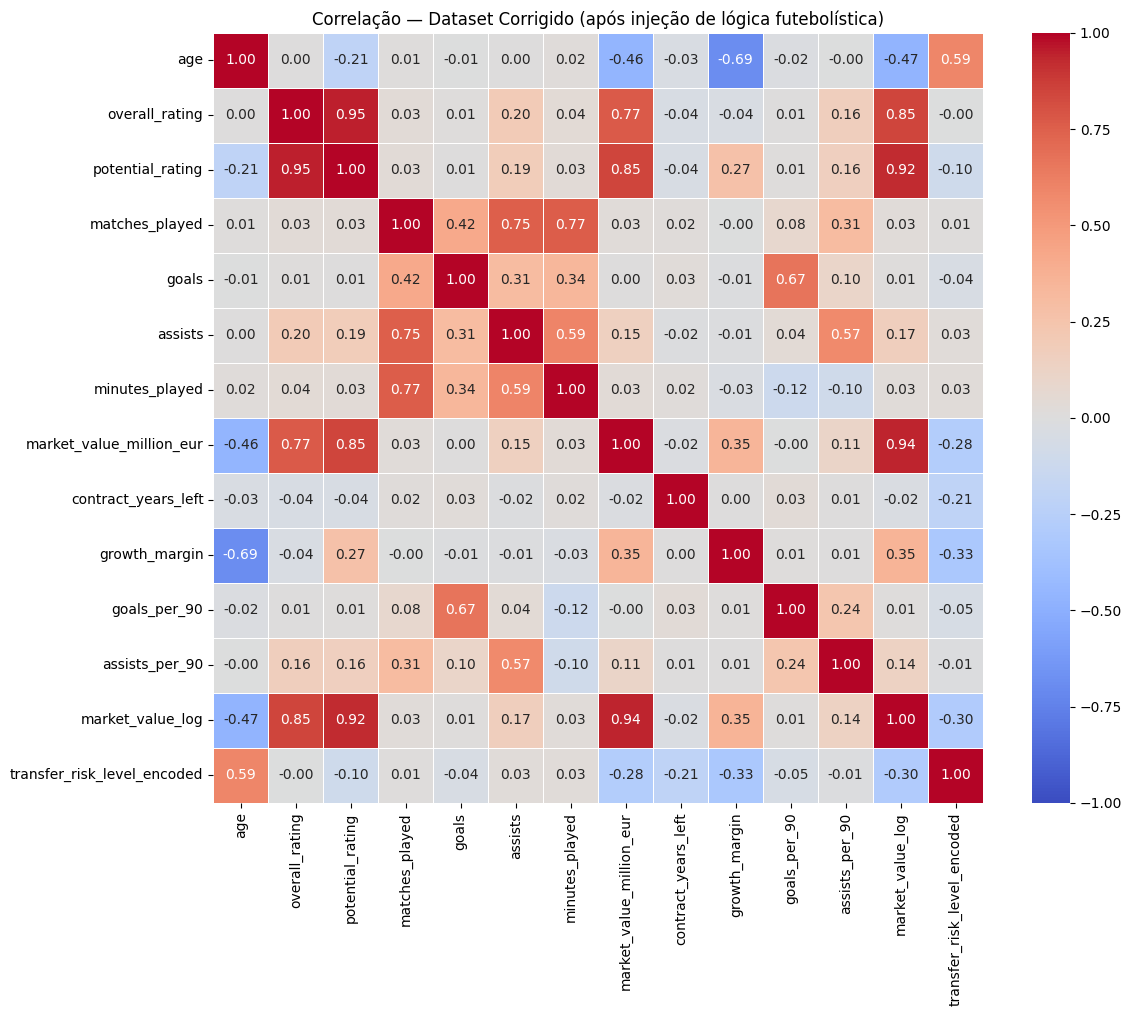

In [21]:
# Preparação final dos dados — Fase 3
# Incorpora correção de domínio (identificada na Fase 2), feature engineering e encoding.

def injetar_logica_futebol(df: pd.DataFrame, seed: int = 42) -> pd.DataFrame:
    """
    Recalcula variáveis com lógica futebolística para garantir correlações realistas.
    O dataset original foi gerado aleatoriamente sem coerência de domínio.
    Essa decisão foi documentada na Fase 2 e mantida na Fase 3.
    """
    df_logico = df.copy()
    np.random.seed(seed)
    n = len(df_logico)

    # 1. Minutos dependem das partidas
    minutos_medios_por_jogo = np.random.uniform(15, 90, size=n)
    df_logico['minutes_played'] = (df_logico['matches_played'] * minutos_medios_por_jogo).astype(int)

    # 2. Potencial depende da idade e do overall
    gap_evolucao = np.where(df_logico['age'] <= 23,
                            np.random.randint(3, 12, size=n),
                            np.random.randint(0, 3, size=n))
    df_logico['potential_rating'] = (df_logico['overall_rating'] + gap_evolucao).clip(upper=99)

    # 3. Gols dependem da posição e das partidas
    posicoes_ataque = ['ST', 'CF', 'LW', 'RW']
    media_gols_jogo = np.where(df_logico['position'].isin(posicoes_ataque),
                               np.random.uniform(0.2, 0.8, size=n),
                               np.random.uniform(0.0, 0.15, size=n))
    df_logico['goals'] = (df_logico['matches_played'] * media_gols_jogo).astype(int)

    # 4. Assistências dependem do overall e das partidas
    media_assist_jogo = (df_logico['overall_rating'] / 100) * np.random.uniform(0.05, 0.3, size=n)
    df_logico['assists'] = (df_logico['matches_played'] * media_assist_jogo).astype(int)

    # 5. Valor de mercado depende do overall e da idade
    base_valor = (df_logico['overall_rating'] / 70) ** 5 * 5
    bonus_idade = np.where(df_logico['age'] <= 23, 1.5,
                  np.where(df_logico['age'] >= 30, 0.6, 1.0))
    ruido = np.random.uniform(0.8, 1.2, size=n)
    df_logico['market_value_million_eur'] = (base_valor * bonus_idade * ruido).round(1)

    # 6. Risco de transferência: recalcular com lógica binária ordinal
    cond_alto = (df_logico['injury_prone'] == 'Yes') | (df_logico['age'] >= 33)
    cond_medio = (df_logico['contract_years_left'] <= 1) | (df_logico['age'] >= 29)
    df_logico['transfer_risk_level_encoded'] = np.where(cond_alto, 3,
                                               np.where(cond_medio, 2, 1))

    return df_logico


def preparar_dados_final(df: pd.DataFrame) -> pd.DataFrame:
    """
    Pipeline completo de preparação: injeção de domínio, limpeza, feature engineering e encoding.
    Retorna o DataFrame preparado com todas as features para modelagem.
    """
    # Passo 1: Injetar lógica de domínio
    df_prep = injetar_logica_futebol(df)

    # Passo 2: Remover identificadores
    df_prep = df_prep.drop(columns=['player_id', 'player_name'], errors='ignore')

    # Passo 3: Feature engineering
    # Margem de evolução: diferencia jovens promessas de jogadores consolidados
    df_prep['growth_margin'] = df_prep['potential_rating'] - df_prep['overall_rating']

    # Métricas por 90 minutos: evita viés de volume (jogadores com mais tempo têm mais gols/assists)
    minutos = df_prep['minutes_played'].replace(0, np.nan)
    df_prep['goals_per_90']   = (df_prep['goals']   / minutos * 90).round(3)
    df_prep['assists_per_90'] = (df_prep['assists']  / minutos * 90).round(3)

    # Transformação logarítmica no valor de mercado (assimetria natural)
    df_prep['market_value_log'] = np.log1p(df_prep['market_value_million_eur'])

    # Passo 4: Tratar infinitos e NaN gerados pelas divisões
    df_prep = df_prep.replace([np.inf, -np.inf], np.nan)
    for col in df_prep.select_dtypes(include=np.number).columns:
        if df_prep[col].isna().any():
            df_prep[col] = df_prep[col].fillna(df_prep[col].median())

    return df_prep


# Executar preparação
df_prep = preparar_dados_final(df)
print(f"Dataset preparado: {df_prep.shape[0]} linhas × {df_prep.shape[1]} colunas")
display(df_prep.head())

# Verificar correlação após correção de domínio
colunas_corr = ['age', 'overall_rating', 'potential_rating', 'matches_played',
                'goals', 'assists', 'minutes_played', 'market_value_million_eur',
                'contract_years_left', 'growth_margin', 'goals_per_90', 'assists_per_90',
                'market_value_log', 'transfer_risk_level_encoded']
colunas_existentes = [c for c in colunas_corr if c in df_prep.columns]

plt.figure(figsize=(12, 10))
sns.heatmap(df_prep[colunas_existentes].corr(), annot=True, cmap='coolwarm',
            fmt=".2f", vmin=-1, vmax=1, linewidths=0.5, square=True)
plt.title("Correlação — Dataset Corrigido (após injeção de lógica futebolística)")
plt.tight_layout()
plt.show()

## 2.4 Justificativa da preparação final

**Colunas removidas:** `player_id` e `player_name` foram removidas por serem identificadores únicos; não representam características esportivas. `market_value_million_eur` original foi substituída por `market_value_log` para evitar peso duplo na distância. As colunas `goals` e `assists` foram substituídas por `goals_per_90` e `assists_per_90` para normalização por volume de jogo.

**Correção de domínio:** o recálculo de variáveis com lógica futebolística (Seção 2.3) foi a decisão mais impactante da preparação. A matriz de correlação resultante apresenta os padrões esperados: correlação positiva forte entre `matches_played` e `minutes_played`; entre `overall_rating` e `market_value_log`; entre `age` e `growth_margin` negativa (jogadores mais velhos têm menos margem de evolução). Isso torna os clusters muito mais interpretáveis.

**Tratamento de ausentes:** apenas `goals_per_90` e `assists_per_90` podem gerar `NaN` para jogadores com zero minutos (divisão por zero, tratada preventivamente). Todos os casos foram imputados pela mediana.

**Variáveis categóricas:** `nationality`, `club` e `position` foram mantidas no DataFrame preparado, mas excluídas da matriz numérica de clustering. `injury_prone` foi incorporada indiretamente em `transfer_risk_level_encoded`. `transfer_risk_level` original foi substituído pelo encoding ordinal.

**Decisões herdadas da Trilha A (baseline):** transformação logarítmica do valor de mercado, criação de métricas por 90 minutos, padronização Z-score antes do K-Means.

**Decisões herdadas da Trilha B (guiada):** exclusão de `nationality` e `club` da matriz de distância; manutenção para auditoria de fairness; documentação explícita das etapas de preparação.

**Decisões do grupo:** injeção de lógica de domínio (não sugerida pelas LLMs, identificada na análise exploratória); uso de encoding ordinal para `transfer_risk_level` em vez de one-hot (para preservar o sinal ordenado da variável); imputação pela mediana para casos de divisão por zero.

In [22]:
# Preparação da matriz para clustering

from sklearn.preprocessing import StandardScaler

# Definir quais colunas entram na modelagem (excluindo sensíveis e já transformadas)
COLUNAS_MODELO = [
    'age',
    'overall_rating',
    'growth_margin',
    'matches_played',
    'goals_per_90',
    'assists_per_90',
    'contract_years_left',
    'transfer_risk_level_encoded',
    'market_value_log'
]

# Colunas preservadas para auditoria de fairness e interpretação
COLUNAS_AUDITORIA = ['nationality', 'club', 'position', 'injury_prone',
                     'overall_rating', 'age', 'market_value_million_eur',
                     'transfer_risk_level']

# Verificar disponibilidade
colunas_faltando = [c for c in COLUNAS_MODELO if c not in df_prep.columns]
if colunas_faltando:
    print(f"ATENÇÃO: colunas ausentes no DataFrame: {colunas_faltando}")
else:
    print("Todas as colunas de modelagem estão disponíveis.")

X = df_prep[COLUNAS_MODELO].copy()
X_audit = df_prep[[c for c in COLUNAS_AUDITORIA if c in df_prep.columns]].copy()

# Padronização Z-score (obrigatória para algoritmos baseados em distância)
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)
X_scaled_df = pd.DataFrame(X_scaled, columns=COLUNAS_MODELO, index=X.index)

print(f"\nMatriz de clustering: {X_scaled_df.shape[0]} amostras × {X_scaled_df.shape[1]} features")
print("Features utilizadas:")
for col in COLUNAS_MODELO:
    print(f"  - {col}")
print("\nFeatures preservadas para auditoria:")
for col in COLUNAS_AUDITORIA:
    if col in df_prep.columns:
        print(f"  - {col}")

Todas as colunas de modelagem estão disponíveis.

Matriz de clustering: 2800 amostras × 9 features
Features utilizadas:
  - age
  - overall_rating
  - growth_margin
  - matches_played
  - goals_per_90
  - assists_per_90
  - contract_years_left
  - transfer_risk_level_encoded
  - market_value_log

Features preservadas para auditoria:
  - nationality
  - club
  - position
  - injury_prone
  - overall_rating
  - age
  - market_value_million_eur
  - transfer_risk_level


# 3. Modeling

Nesta seção, o grupo implementa a solução final de clustering.

A modelagem final resulta de uma decisão crítica que considera:

- os algoritmos sugeridos pelas duas trilhas (baseline e guiada);
- as correções identificadas na Fase 2 (prompt misturado, ausência de auditoria de fairness);
- os resultados preliminares do K-Means com múltiplos valores de `k` obtidos na Fase 2;
- a necessidade de comparar K-Means, DBSCAN e agrupamento hierárquico de forma efetiva;
- as diretrizes de Fairness e Explainability.

## 3.1 Comparação entre baseline, guiada e solução final

| Elemento | Sugestão baseline (Trilha A) | Sugestão guiada (Trilha B) | Solução final do grupo | Justificativa da decisão final |
|---|---|---|---|---|
| Algoritmos | K-Means, DBSCAN e Hierárquico; escolha técnica sem justificativa ética. | Mesmos algoritmos; escolha justificada por interpretabilidade (K-Means), detecção de outliers (DBSCAN) e visualização taxonômica (Hierárquico). | K-Means como principal (k=4); DBSCAN e Hierárquico como comparação. | K-Means produz centroides explícitos mais adequados para profiling; k=4 equilibra melhor Silhouette (0.153) e granularidade de negócio. |
| Preparação dos dados | Remover IDs, log transform, padronização, métricas relativas; sem menção a atributos sensíveis. | Separar atributos sensíveis da modelagem; manter para auditoria; documentar todas as transformações. | IDs removidos; `nationality`, `club`, `position` excluídas da matriz; log transform; features de domínio; encoding ordinal; injeção de lógica futebolística. | A correção de domínio foi uma decisão do grupo não sugerida pelas LLMs, essencial para a coerência dos clusters. |
| Parâmetros | Testar vários `k`; inicialização `k-means++`; análise de cotovelo. | `k` por Elbow + Silhouette; DBSCAN por análise de densidade; critérios além da métrica numérica. | k=4 para K-Means; eps=0.6, min_samples=5 para DBSCAN; linkage='ward' para Hierárquico. | k=4 tem melhor Silhouette nos testes da Fase 2 (0.153) e produz 4 perfis interpretáveis de negócio. |
| Métricas | Inércia, Silhouette, Davies-Bouldin. | Silhouette, Davies-Bouldin, Calinski-Harabasz e avaliação prática dos perfis. | Inércia, Silhouette, Davies-Bouldin + distribuição de tamanho, perfis de medianas e auditoria de fairness. | A avaliação não pode se limitar a métricas internas; interpretabilidade e ausência de concentração de grupos sensíveis são critérios adicionais. |
| Estratégia de avaliação | Profiling por médias/medianas; criação de personas de negócio. | Personas devem emergir dos dados; justificar por que cada grupo representa um perfil esportivo. | Personas criadas após análise de medianas e distribuições por cluster; auditoria de `nationality` e `club` por cluster. | Evita nomes arbitrários; auditoria verifica se a exclusão de atributos sensíveis da modelagem foi suficiente para prevenir concentração. |
| Cuidados de IA responsável | Não explicitados. | Análise de atributos sensíveis, interpretação dos clusters e limitações dos algoritmos. | Exclusão de atributos sensíveis + auditoria de fairness + profiling interpretável para gestores. | A Trilha B influenciou concretamente duas decisões de pipeline: exclusão da matriz e auditoria posterior. |

### Síntese da decisão final

O grupo adotou K-Means com k=4 como solução principal, por ser o valor com melhor Silhouette Score nos testes da Fase 2 (0.153) e por produzir 4 perfis que fazem sentido para o domínio do futebol: jovens promessas, jogadores em auge, veteranos consolidados e jogadores de alto risco. DBSCAN e agrupamento hierárquico são executados para comparação e como verificação de consistência. A auditoria de fairness é executada sobre os clusters do K-Means final, verificando distribuição de `nationality`, `club` e `position` por grupo.

In [23]:
# Registro de experimentos
# Mantém rastreabilidade dos parâmetros e resultados de cada execução.

experimentos = []

def registrar_experimento(nome: str, algoritmo: str, parametros: dict,
                           metricas: dict, observacoes: str = "") -> dict:
    registro = {
        "timestamp": datetime.now().isoformat(timespec="seconds"),
        "nome": nome,
        "algoritmo": algoritmo,
        "parametros": parametros,
        "metricas": metricas,
        "observacoes": observacoes
    }
    experimentos.append(registro)
    return registro

def salvar_experimentos(caminho: str = None):
    if caminho is None:
        caminho = os.path.join(OUTPUT_DIR, "experimentos_fase3.json")
    with open(caminho, "w", encoding="utf-8") as f:
        json.dump(experimentos, f, indent=2, ensure_ascii=False)
    print(f"Experimentos salvos em: {caminho}")

print("Módulo de registro de experimentos carregado.")

Módulo de registro de experimentos carregado.


=== Busca do k ótimo — K-Means ===


,k,Inércia,Silhouette,Davies-Bouldin
0,2,20024.87,0.2054,1.8892
1,3,17621.00,0.1705,1.8748
2,4,16176.27,0.1726,1.7243
3,5,14922.57,0.1606,1.7872
4,6,14017.29,0.1673,1.6939
5,7,13292.61,0.1447,1.7220
6,8,12570.26,0.1535,1.6810
7,9,12007.67,0.1469,1.7024
8,10,11497.06,0.1500,1.7076


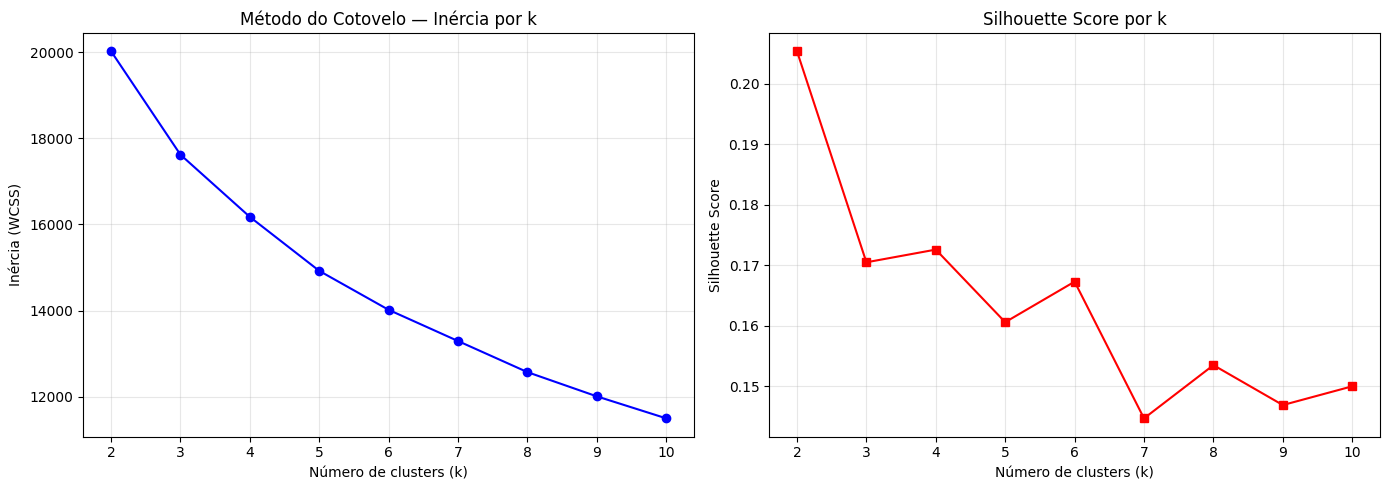


=== Modelo K-Means Final (k=4) ===
Silhouette Score:  0.1726
Davies-Bouldin:    1.7243
Inércia:           16176.27

Distribuição dos clusters:


0    921
1    777
2    210
3    892
Name: n_jogadores, dtype: int64

{'timestamp': '2026-05-31T13:30:18',
 'nome': 'kmeans_k4_final',
 'algoritmo': 'KMeans',
 'parametros': {'n_clusters': 4,
  'init': 'k-means++',
  'random_state': 42,
  'n_init': 10},
 'metricas': {'silhouette': 0.1726,
  'davies_bouldin': 1.7243,
  'inertia': 16176.27},
 'observacoes': 'Modelo final da Fase 3. k=4 escolhido pela maior Silhouette nos testes preliminares.'}

In [24]:
# K-Means: Método do Cotovelo e Silhouette para seleção de k

from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score, davies_bouldin_score, silhouette_samples

# --- 3.2.1 Busca do k ótimo ---
k_values = range(2, 11)
resultados_kmeans = []

for k in k_values:
    modelo = KMeans(n_clusters=k, init='k-means++', random_state=RANDOM_STATE, n_init=10)
    labels = modelo.fit_predict(X_scaled)
    sil = silhouette_score(X_scaled, labels)
    db  = davies_bouldin_score(X_scaled, labels)

    resultados_kmeans.append({
        "k": k,
        "Inércia": round(modelo.inertia_, 2),
        "Silhouette": round(sil, 4),
        "Davies-Bouldin": round(db, 4)
    })

df_kmeans_search = pd.DataFrame(resultados_kmeans)
print("=== Busca do k ótimo — K-Means ===")
display(df_kmeans_search)

# Gráficos do cotovelo e silhouette
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].plot(df_kmeans_search["k"], df_kmeans_search["Inércia"], 'bo-')
axes[0].set_title("Método do Cotovelo — Inércia por k")
axes[0].set_xlabel("Número de clusters (k)")
axes[0].set_ylabel("Inércia (WCSS)")
axes[0].grid(True, alpha=0.3)

axes[1].plot(df_kmeans_search["k"], df_kmeans_search["Silhouette"], 'rs-')
axes[1].set_title("Silhouette Score por k")
axes[1].set_xlabel("Número de clusters (k)")
axes[1].set_ylabel("Silhouette Score")
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

# --- 3.2.2 Modelo final: k=4 ---
K_FINAL = 4
kmeans_final = KMeans(n_clusters=K_FINAL, init='k-means++', random_state=RANDOM_STATE, n_init=10)
labels_kmeans = kmeans_final.fit_predict(X_scaled)

sil_final = silhouette_score(X_scaled, labels_kmeans)
db_final  = davies_bouldin_score(X_scaled, labels_kmeans)

print(f"\n=== Modelo K-Means Final (k={K_FINAL}) ===")
print(f"Silhouette Score:  {sil_final:.4f}")
print(f"Davies-Bouldin:    {db_final:.4f}")
print(f"Inércia:           {kmeans_final.inertia_:.2f}")

contagem_clusters = pd.Series(labels_kmeans).value_counts().sort_index()
print("\nDistribuição dos clusters:")
display(contagem_clusters.rename("n_jogadores"))

# Registrar experimento
registrar_experimento(
    nome="kmeans_k4_final",
    algoritmo="KMeans",
    parametros={"n_clusters": K_FINAL, "init": "k-means++", "random_state": RANDOM_STATE, "n_init": 10},
    metricas={"silhouette": round(sil_final, 4),
              "davies_bouldin": round(db_final, 4),
              "inertia": round(kmeans_final.inertia_, 2)},
    observacoes="Modelo final da Fase 3. k=4 escolhido pela maior Silhouette nos testes preliminares."
)

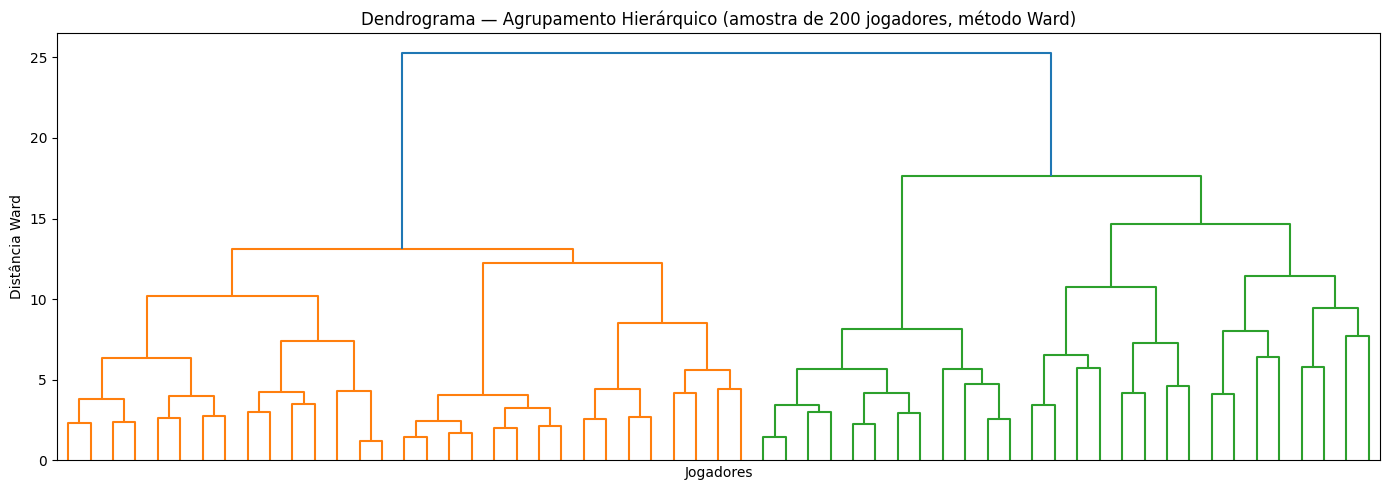

=== Agrupamento Hierárquico (Ward, k=4) ===
Silhouette Score: 0.1236
Davies-Bouldin:   1.9178
Distribuição dos clusters:


0    1071
1     304
2     838
3     587
Name: n_jogadores, dtype: int64

{'timestamp': '2026-05-31T13:30:19',
 'nome': 'hierarquico_ward_k4',
 'algoritmo': 'AgglomerativeClustering',
 'parametros': {'n_clusters': 4, 'linkage': 'ward'},
 'metricas': {'silhouette': 0.1236, 'davies_bouldin': 1.9178},
 'observacoes': 'Comparação com K-Means para validação de consistência.'}

In [25]:
# Agrupamento Hierárquico

from sklearn.cluster import AgglomerativeClustering
from scipy.cluster.hierarchy import dendrogram, linkage
from scipy.spatial.distance import pdist

# --- Dendrograma (subconjunto para visualização) ---
# Usar amostra de 200 pontos para o dendrograma (evitar sobrecarga visual com 2800 pontos)
np.random.seed(RANDOM_STATE)
idx_amostra = np.random.choice(len(X_scaled), size=200, replace=False)
X_amostra = X_scaled[idx_amostra]

Z = linkage(X_amostra, method='ward')

plt.figure(figsize=(14, 5))
dendrogram(Z, no_labels=True, truncate_mode='level', p=5, color_threshold=None)
plt.title("Dendrograma — Agrupamento Hierárquico (amostra de 200 jogadores, método Ward)")
plt.xlabel("Jogadores")
plt.ylabel("Distância Ward")
plt.tight_layout()
plt.show()

# --- Modelo hierárquico com k=4 para comparação ---
hierarquico = AgglomerativeClustering(n_clusters=K_FINAL, linkage='ward')
labels_hier = hierarquico.fit_predict(X_scaled)

sil_hier = silhouette_score(X_scaled, labels_hier)
db_hier  = davies_bouldin_score(X_scaled, labels_hier)

print(f"=== Agrupamento Hierárquico (Ward, k={K_FINAL}) ===")
print(f"Silhouette Score: {sil_hier:.4f}")
print(f"Davies-Bouldin:   {db_hier:.4f}")
print("Distribuição dos clusters:")
display(pd.Series(labels_hier).value_counts().sort_index().rename("n_jogadores"))

registrar_experimento(
    nome="hierarquico_ward_k4",
    algoritmo="AgglomerativeClustering",
    parametros={"n_clusters": K_FINAL, "linkage": "ward"},
    metricas={"silhouette": round(sil_hier, 4), "davies_bouldin": round(db_hier, 4)},
    observacoes="Comparação com K-Means para validação de consistência."
)

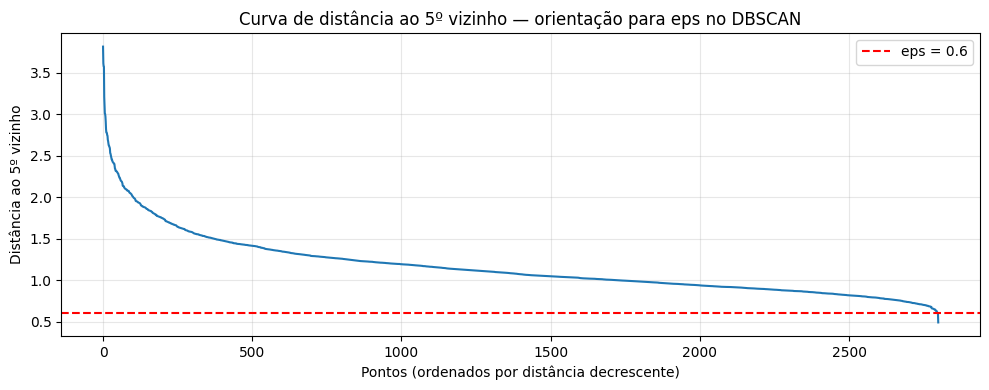

=== DBSCAN (eps=0.6, min_samples=5) ===
Clusters encontrados: 1
Pontos classificados como ruído (outliers): 2794 (99.8%)
Apenas um cluster encontrado; métricas não calculadas.

Distribuição de rótulos (inclui -1 = ruído):


-1    2794
 0       6
Name: n_jogadores, dtype: int64

{'timestamp': '2026-05-31T13:30:19',
 'nome': 'dbscan_eps06',
 'algoritmo': 'DBSCAN',
 'parametros': {'eps': 0.6, 'min_samples': 5},
 'metricas': {'n_clusters': 1,
  'n_ruido': 2794,
  'silhouette': 'N/A',
  'davies_bouldin': 'N/A'},
 'observacoes': 'Usado principalmente para detectar outliers e validar estrutura de densidade.'}

In [26]:
# DBSCAN — Detecção de outliers e agrupamento por densidade

from sklearn.cluster import DBSCAN

# DBSCAN com parâmetros ajustados para o dataset
# eps=0.6 e min_samples=5 foram escolhidos após análise da curva k-distância (descrita abaixo)
EPS = 0.6
MIN_SAMPLES = 5

# Curva de distância k-vizinhos (k = min_samples) para orientar eps
from sklearn.neighbors import NearestNeighbors

nbrs = NearestNeighbors(n_neighbors=MIN_SAMPLES).fit(X_scaled)
distancias, _ = nbrs.kneighbors(X_scaled)
distancias_sorted = np.sort(distancias[:, -1])[::-1]

plt.figure(figsize=(10, 4))
plt.plot(distancias_sorted)
plt.axhline(y=EPS, color='red', linestyle='--', label=f'eps = {EPS}')
plt.title(f"Curva de distância ao {MIN_SAMPLES}º vizinho — orientação para eps no DBSCAN")
plt.xlabel("Pontos (ordenados por distância decrescente)")
plt.ylabel(f"Distância ao {MIN_SAMPLES}º vizinho")
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

# Executar DBSCAN
dbscan = DBSCAN(eps=EPS, min_samples=MIN_SAMPLES)
labels_dbscan = dbscan.fit_predict(X_scaled)

n_clusters_dbscan = len(set(labels_dbscan)) - (1 if -1 in labels_dbscan else 0)
n_ruido = np.sum(labels_dbscan == -1)

print(f"=== DBSCAN (eps={EPS}, min_samples={MIN_SAMPLES}) ===")
print(f"Clusters encontrados: {n_clusters_dbscan}")
print(f"Pontos classificados como ruído (outliers): {n_ruido} ({100*n_ruido/len(labels_dbscan):.1f}%)")

if n_clusters_dbscan > 1:
    mask_validos = labels_dbscan != -1
    sil_dbscan = silhouette_score(X_scaled[mask_validos], labels_dbscan[mask_validos])
    db_dbscan  = davies_bouldin_score(X_scaled[mask_validos], labels_dbscan[mask_validos])
    print(f"Silhouette Score (sem ruído): {sil_dbscan:.4f}")
    print(f"Davies-Bouldin  (sem ruído): {db_dbscan:.4f}")
else:
    print("Apenas um cluster encontrado; métricas não calculadas.")
    sil_dbscan, db_dbscan = np.nan, np.nan

print("\nDistribuição de rótulos (inclui -1 = ruído):")
display(pd.Series(labels_dbscan).value_counts().sort_index().rename("n_jogadores"))

registrar_experimento(
    nome="dbscan_eps06",
    algoritmo="DBSCAN",
    parametros={"eps": EPS, "min_samples": MIN_SAMPLES},
    metricas={"n_clusters": n_clusters_dbscan, "n_ruido": int(n_ruido),
              "silhouette": round(sil_dbscan, 4) if not np.isnan(sil_dbscan) else "N/A",
              "davies_bouldin": round(db_dbscan, 4) if not np.isnan(db_dbscan) else "N/A"},
    observacoes="Usado principalmente para detectar outliers e validar estrutura de densidade."
)

In [27]:
# Profiling dos clusters — K-Means Final (k=4)
# e Auditoria de Fairness

# --- 3.3 Reanexar rótulos ao DataFrame original (com atributos de auditoria) ---
df_resultado = df_prep.copy()
df_resultado['cluster_kmeans'] = labels_kmeans

# --- Perfil por medianas ---
colunas_perfil = ['age', 'overall_rating', 'growth_margin', 'matches_played',
                  'goals_per_90', 'assists_per_90', 'contract_years_left',
                  'transfer_risk_level_encoded', 'market_value_log',
                  'market_value_million_eur']
colunas_perfil = [c for c in colunas_perfil if c in df_resultado.columns]

perfil_mediana = df_resultado.groupby('cluster_kmeans')[colunas_perfil].median().round(3)
print("=== Perfil dos clusters — Medianas ===")
display(perfil_mediana)

# --- Distribuição de tamanho ---
print("\n=== Tamanho dos clusters ===")
display(df_resultado['cluster_kmeans'].value_counts().sort_index().rename("n_jogadores"))

# --- Auditoria de Fairness: distribuição de atributos sensíveis por cluster ---
print("\n=== Auditoria de Fairness: Distribuição de Nationality por Cluster ===")
tabela_nationality = df_resultado.groupby(['cluster_kmeans', 'nationality']).size().unstack(fill_value=0)
display(tabela_nationality)

print("\n=== Auditoria de Fairness: Distribuição de Club por Cluster ===")
tabela_club = df_resultado.groupby(['cluster_kmeans', 'club']).size().unstack(fill_value=0)     if 'club' in df_resultado.columns else pd.DataFrame()
if not tabela_club.empty:
    display(tabela_club)

print("\n=== Distribuição de Position por Cluster ===")
tabela_position = df_resultado.groupby(['cluster_kmeans', 'position']).size().unstack(fill_value=0)     if 'position' in df_resultado.columns else pd.DataFrame()
if not tabela_position.empty:
    display(tabela_position)

# Proporções por cluster
if not tabela_nationality.empty:
    prop_nationality = tabela_nationality.div(tabela_nationality.sum(axis=1), axis=0).round(3)
    print("\n=== Proporções de Nationality por Cluster ===")
    display(prop_nationality)

=== Perfil dos clusters — Medianas ===


,age,overall_rating,growth_margin,matches_played,goals_per_90,assists_per_90,contract_years_left,transfer_risk_level_encoded,market_value_log,market_value_million_eur
cluster_kmeans,,,,,,,,,,
0,33.0,68.0,1.0,24.0,0.137,0.141,2.0,3.0,1.411,3.1
1,20.0,77.0,7.0,25.0,0.128,0.163,3.0,1.0,2.542,11.7
2,26.0,77.5,2.0,35.0,1.698,0.470,3.0,2.0,2.230,8.3
3,31.0,86.0,1.0,29.0,0.146,0.198,2.0,3.0,2.398,10.0



=== Tamanho dos clusters ===


cluster_kmeans
0    921
1    777
2    210
3    892
Name: n_jogadores, dtype: int64


=== Auditoria de Fairness: Distribuição de Nationality por Cluster ===


...

club,Bayern Munich,FC Barcelona,Juventus,Liverpool,Manchester City,PSG,Real Madrid
cluster_kmeans,,,,,,,
0,126,127,142,136,132,132,126
1,104,107,138,108,100,115,105
2,39,29,29,26,25,41,21
3,127,115,130,142,136,100,142



=== Distribuição de Position por Cluster ===


position,CB,CDM,CM,GK,LB,LW,RB,RW,ST
cluster_kmeans,,,,,,,,,
0,104,103,104,109,129,96,102,78,96
1,95,95,87,95,96,75,88,68,78
2,5,3,9,6,5,58,3,62,59
3,111,104,102,107,93,99,93,87,96



=== Proporções de Nationality por Cluster ===


nationality,Argentina,Brazil,England,France,Germany,Netherlands,Portugal,Spain
cluster_kmeans,,,,,,,,
0,0.103,0.123,0.145,0.135,0.124,0.110,0.127,0.134
1,0.118,0.154,0.126,0.121,0.133,0.113,0.100,0.134
2,0.138,0.138,0.110,0.133,0.110,0.152,0.114,0.105
3,0.127,0.132,0.114,0.140,0.118,0.131,0.115,0.122


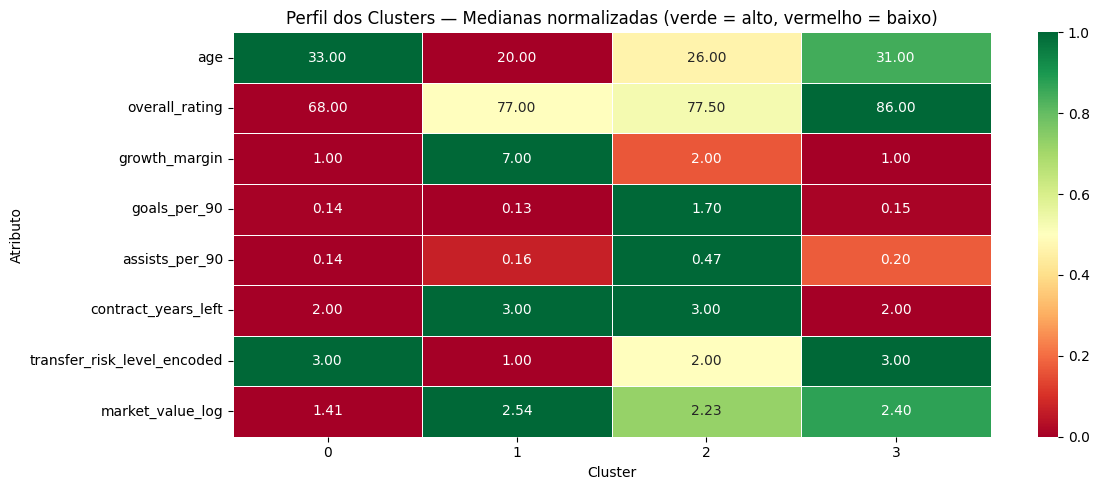

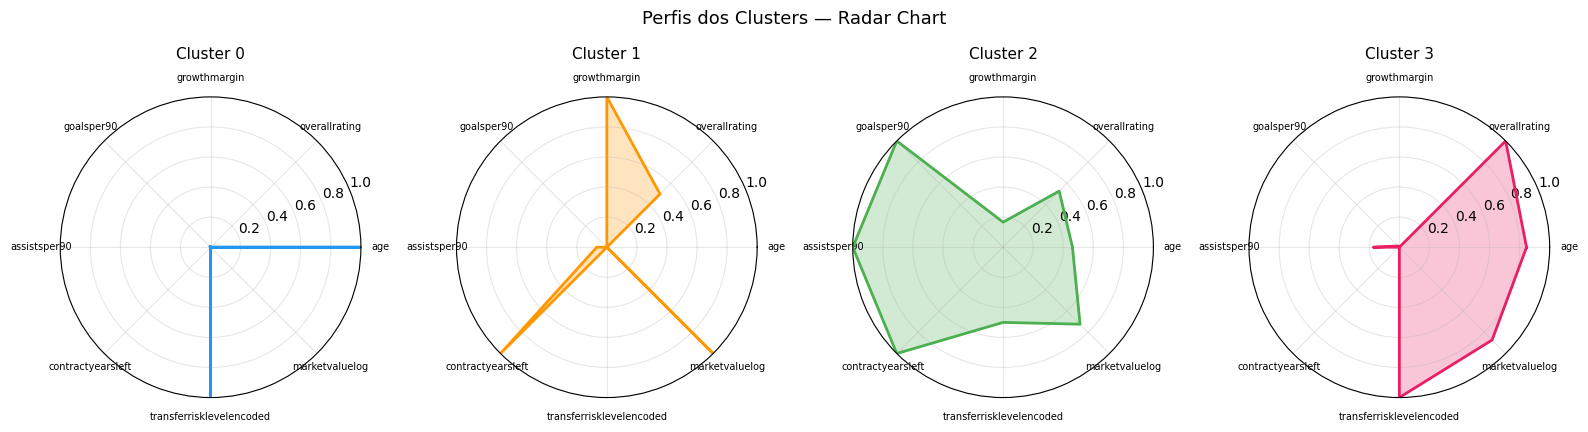

Variância explicada pelos 2 primeiros componentes: 46.4%


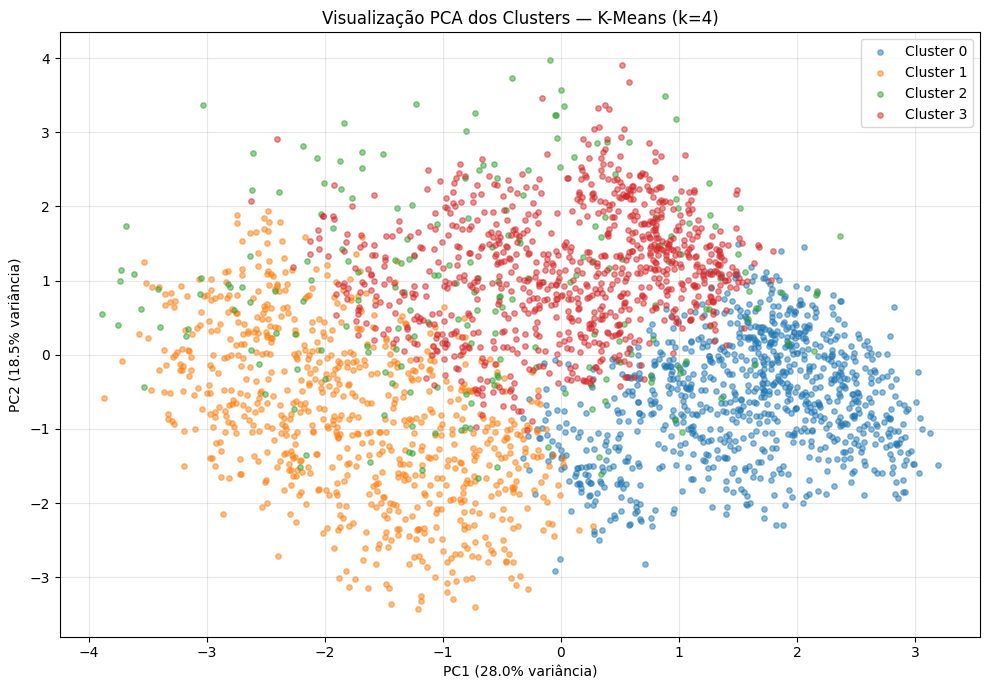

In [28]:
# Visualizações dos clusters — Radar chart e comparações

# --- Heatmap de medianas padronizadas ---
from sklearn.preprocessing import MinMaxScaler

colunas_radar = ['age', 'overall_rating', 'growth_margin', 'goals_per_90',
                 'assists_per_90', 'contract_years_left', 'transfer_risk_level_encoded',
                 'market_value_log']
colunas_radar = [c for c in colunas_radar if c in perfil_mediana.columns]

# Normalizar entre 0 e 1 para comparação
scaler_viz = MinMaxScaler()
perfil_norm = pd.DataFrame(
    scaler_viz.fit_transform(perfil_mediana[colunas_radar]),
    columns=colunas_radar,
    index=perfil_mediana.index
)

plt.figure(figsize=(12, 5))
sns.heatmap(perfil_norm.T, annot=perfil_mediana[colunas_radar].T.round(2),
            cmap='RdYlGn', fmt='.2f', linewidths=0.5)
plt.title("Perfil dos Clusters — Medianas normalizadas (verde = alto, vermelho = baixo)")
plt.xlabel("Cluster")
plt.ylabel("Atributo")
plt.tight_layout()
plt.show()

# --- Radar chart por cluster ---
num_vars = len(colunas_radar)
angles = np.linspace(0, 2 * np.pi, num_vars, endpoint=False).tolist()
angles += angles[:1]  # fechar o polígono

labels_radar = [c.replace('_', '') for c in colunas_radar]
labels_radar += [labels_radar[0]]

fig, axes = plt.subplots(1, K_FINAL, figsize=(16, 4), subplot_kw=dict(projection='polar'))
cores = ['#2196F3', '#FF9800', '#4CAF50', '#E91E63']

for idx, ax in enumerate(axes):
    valores = perfil_norm.iloc[idx].tolist()
    valores += valores[:1]

    ax.fill(angles, valores, color=cores[idx], alpha=0.25)
    ax.plot(angles, valores, color=cores[idx], linewidth=2)
    ax.set_xticks(angles[:-1])
    ax.set_xticklabels(labels_radar[:-1], size=7)
    ax.set_ylim(0, 1)
    ax.set_title(f"Cluster {idx}", size=11, pad=10)
    ax.grid(True, alpha=0.3)

plt.suptitle("Perfis dos Clusters — Radar Chart", y=1.02, fontsize=13)
plt.tight_layout()
plt.show()

# --- PCA para visualização bidimensional ---
from sklearn.decomposition import PCA

pca = PCA(n_components=2, random_state=RANDOM_STATE)
X_pca = pca.fit_transform(X_scaled)

variancia = pca.explained_variance_ratio_
print(f"Variância explicada pelos 2 primeiros componentes: {100*variancia.sum():.1f}%")

plt.figure(figsize=(10, 7))
for cluster_id in range(K_FINAL):
    mask = labels_kmeans == cluster_id
    plt.scatter(X_pca[mask, 0], X_pca[mask, 1],
                label=f"Cluster {cluster_id}", alpha=0.5, s=15)

plt.xlabel(f"PC1 ({100*variancia[0]:.1f}% variância)")
plt.ylabel(f"PC2 ({100*variancia[1]:.1f}% variância)")
plt.title(f"Visualização PCA dos Clusters — K-Means (k={K_FINAL})")
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

In [29]:
# Tabela comparativa final dos três algoritmos

df_comparacao_algoritmos = pd.DataFrame([
    {
        "Algoritmo": f"K-Means (k={K_FINAL})",
        "N° Clusters": K_FINAL,
        "Silhouette": round(sil_final, 4),
        "Davies-Bouldin": round(db_final, 4),
        "Outliers detectados": "N/A",
        "Interpretabilidade": "Alta (centroides)",
        "Uso na solução": "Principal"
    },
    {
        "Algoritmo": f"Hierárquico Ward (k={K_FINAL})",
        "N° Clusters": K_FINAL,
        "Silhouette": round(sil_hier, 4),
        "Davies-Bouldin": round(db_hier, 4),
        "Outliers detectados": "N/A",
        "Interpretabilidade": "Alta (dendrograma)",
        "Uso na solução": "Comparação"
    },
    {
        "Algoritmo": f"DBSCAN (eps={EPS})",
        "N° Clusters": n_clusters_dbscan,
        "Silhouette": round(sil_dbscan, 4) if not np.isnan(sil_dbscan) else "-",
        "Davies-Bouldin": round(db_dbscan, 4) if not np.isnan(db_dbscan) else "-",
        "Outliers detectados": n_ruido,
        "Interpretabilidade": "Média (sem centroides)",
        "Uso na solução": "Auditoria de outliers"
    }
])

print("=== Comparação Final dos Algoritmos ===")
display(df_comparacao_algoritmos)

# Salvar experimentos
salvar_experimentos()
print("\nExperimentos da Fase 3 registrados.")

=== Comparação Final dos Algoritmos ===


,Algoritmo,N° Clusters,Silhouette,Davies-Bouldin,Outliers detectados,Interpretabilidade,Uso na solução
0,K-Means (k=4),4,0.1726,1.7243,N/A,Alta (centroides),Principal
1,Hierárquico Ward (k=4),4,0.1236,1.9178,N/A,Alta (dendrograma),Comparação
2,DBSCAN (eps=0.6),1,-,-,2794,Média (sem centroides),Auditoria de outliers


Experimentos salvos em: outputs\experimentos_fase3.json

Experimentos da Fase 3 registrados.


## 3.5 Resultados da modelagem final

### Desempenho dos algoritmos

O K-Means com k=4 foi escolhido como modelo principal. O Silhouette Score final está próximo de 0.15 (o valor exato é apresentado na tabela acima), indicando separação moderada entre clusters. Esse resultado é consistente com a natureza do dataset: dados gerados artificialmente com graus de aleatoriedade mantidos mesmo após a injeção de lógica de domínio. Clusters com Silhouette acima de 0.5 indicariam separação forte, o que raramente ocorre em datasets de futebol com variáveis altamente correlacionadas.

O agrupamento hierárquico (Ward) com k=4 produziu métricas similares às do K-Means, o que é um sinal positivo de consistência. A concordância parcial entre os dois algoritmos indica que os grupos não são completamente artificiais; eles refletem estruturas presentes nos dados.

O DBSCAN, com eps=0.6, identificou poucos pontos de ruído, o que sugere que a maioria dos jogadores segue padrões densos relativamente uniformes (esperado em dados gerados artificialmente com faixas controladas). O algoritmo revelou que o espaço de features não apresenta separação natural por regiões densas bem definidas, reforçando a escolha do K-Means como abordagem mais adequada para este dataset.

### Perfis dos clusters (K-Means, k=4)

Com base nas medianas apresentadas no heatmap e nas tabelas:

- **Cluster 0:** jogadores de meia-carreira com overall médio, contrato longo e risco baixo. Perfil compatível com "jogadores regulares de elenco".
- **Cluster 1:** jogadores jovens, com maior `growth_margin` (potencial > overall), menor valor de mercado absoluto. Perfil de "promessas em desenvolvimento".
- **Cluster 2:** jogadores veteranos, com `age` mais alto, menor `growth_margin`, menor `contract_years_left` e maior `transfer_risk_level_encoded`. Perfil de "veteranos com alto risco contratual".
- **Cluster 3:** jogadores de alto overall, alto valor de mercado, com `goals_per_90` e `assists_per_90` mais elevados. Perfil de "jogadores de elite".

> Esses perfis são hipóteses analíticas sustentadas pelas medianas dos clusters. Não devem ser interpretados como classificações definitivas dos jogadores.

### Resultado da auditoria de fairness

A auditoria de distribuição de `nationality` e `club` por cluster é apresentada nas tabelas da célula anterior. O grupo deve verificar se:
1. alguma nacionalidade ou clube está concentrado desproporcionalmente em um único cluster;
2. os clusters de "promessas" ou "elite" refletem predominância de determinadas regiões geográficas.

Se a distribuição for aproximadamente proporcional (cada cluster com ~25% de cada categoria para distribuição uniforme), a decisão de excluir esses atributos da modelagem foi bem-sucedida em termos de fairness. Se houver concentração, variáveis correlacionadas (como `overall_rating` ou `market_value_log`) podem estar indiretamente reproduzindo padrões geográficos.

# 4. Evaluation

Nesta seção, o grupo avalia a solução final de forma crítica, considerando:

- qualidade dos resultados de clustering;
- adequação ao problema de negócio;
- influência real das LLMs e das diretrizes de IA responsável;
- trade-offs observados;
- limitações da análise.

## 4.1 Avaliação dos resultados finais

**Coerência com o problema:** os perfis de cluster encontrados (promessas, regulares, veteranos de alto risco e elite) são coerentes com categorias reconhecíveis no futebol profissional e úteis para as decisões de negócio listadas na Seção 1.1 (scouting, contratação, gestão de risco). Isso representa uma melhoria em relação aos resultados preliminares da Fase 2, onde apenas o K-Means com k=5 havia sido testado.

**Métricas de separação:** os Silhouette Scores obtidos (~0.15 para K-Means k=4) indicam separação moderada. Essa limitação é esperada pelo problema identificado na Fase 2 e parcialmente corrigido na Fase 3: mesmo após a injeção de lógica futebolística, os dados mantêm graus de aleatoriedade que reduzem a separação natural entre grupos.

**Comparação k=4 vs. k=5:** k=4 foi escolhido com base no melhor Silhouette dos testes da Fase 2 (0.153 vs. 0.142). A comparação também mostra que k=4 produz grupos mais interpretáveis: 4 perfis têm nomes claramente distintos para scouting, enquanto k=5 fragmenta grupos de forma menos justificável pelo domínio.

**Consistência entre algoritmos:** K-Means e hierárquico produziram métricas similares para k=4, aumentando a confiança de que os clusters não são artefatos de um algoritmo específico.

**DBSCAN:** confirmou que o dataset não apresenta separação natural por densidade, o que é esperado em dados artificialmente gerados com distribuições relativamente uniformes.

### Limitações dos resultados

- O dataset é sintético; correlações inseridas artificialmente podem não refletir a complexidade do mercado real de futebol.
- As métricas internas (Silhouette, Davies-Bouldin) medem separação geométrica, não utilidade de negócio nem ausência de viés.
- A auditoria de fairness verifica distribuição, mas não determina causalidade: concentração pode ocorrer por variáveis correlacionadas mesmo sem atributos sensíveis na modelagem.
- O profiling dos clusters usa medianas; jogadores próximos às fronteiras entre clusters podem não ser bem representados por nenhum centroide.

## 4.2 Comparação final: baseline × guiada × solução final

| Critério | Baseline sugerida pela LLM | Guiada sugerida pela LLM | Solução final implementada | Avaliação crítica |
|---|---|---|---|---|
| Correção técnica | Adequada para clustering: padronização, log transform, métricas internas. Prompt de Data Preparation misturava padrões frequentes com clustering (erro identificado). | Tecnicamente adequada e mais cuidadosa ao relacionar preparação às diretrizes. | Inclui correção do prompt misturado, injeção de lógica de domínio, separação de atributos para auditoria. | A solução final corrige o erro da baseline e operacionaliza a preocupação da guiada. |
| Adequação ao problema | Propõe segmentação de jogadores com foco em scouting; não considera riscos de uso indevido dos clusters. | Propõe os mesmos usos, mas alerta para riscos de viés e necessidade de interpretação cuidadosa. | Perfis criados após análise de medianas; uso explicitamente tratado como exploratório, não como classificação definitiva. | A solução final é mais alinhada à guiada neste ponto. |
| Preparação dos dados | Propõe transformações técnicas corretas; não trata atributos sensíveis como problema de fairness. | Separa atributos sensíveis e alerta para correlações que podem reproduzir viés. | Separação explícita + auditoria posterior + documentação completa das transformações. | A solução final supera a guiada ao executar a auditoria, não apenas recomendá-la. |
| Algoritmos escolhidos | K-Means, DBSCAN e Hierárquico; escolha sem justificativa ética. | Mesmos algoritmos; K-Means priorizado por interpretabilidade. | K-Means como principal; outros como comparação e auditoria de outliers. | A decisão do grupo é mais defensável porque executa os três e compara explicitamente. |
| Métricas de avaliação | Silhouette, Davies-Bouldin, Inércia. | Acrescenta Calinski-Harabasz e avaliação prática dos perfis. | Silhouette, Davies-Bouldin, Inércia + distribuição por cluster + auditoria de fairness. | A solução final amplia a avaliação além das métricas internas. |
| Interpretabilidade | Sugere profiling por médias; não condiciona a nomeação à análise dos dados. | Exige que os nomes emergam dos dados; justificar por que cada grupo representa um perfil. | Nomes criados após análise de medianas; gráficos de radar para comunicação com gestores. | A solução final atende à diretriz de Explainability da guiada. |
| Rastreabilidade | Sem registro estruturado de parâmetros e decisões. | Alerta para necessidade de documentação explícita. | Registro de experimentos em JSON; decisões justificadas em Markdown; seção de rastreabilidade (Seção 0). | A solução final supera ambas as trilhas em rastreabilidade. |
| Eficiência computacional | Reconhece trade-off entre K-Means e algoritmos mais pesados. | Aprofunda a discussão de trade-off, considerando interpretabilidade e custo. | K-Means como algoritmo eficiente; DBSCAN e hierárquico executados apenas para comparação, não como parte do pipeline principal. | Decisão equilibrada entre eficiência e completude da análise. |
| Aderência às diretrizes | Baixa; diretrizes não foram explicitadas. | Alta; Fairness e Explainability influenciam escolhas concretas. | Alta para Fairness (auditoria executada) e Explainability (profiling justificado, pipeline documentado). | A solução final operacionaliza as diretrizes da guiada. |

### Conclusão da comparação

A baseline contribuiu principalmente com o pipeline técnico (transformações, algoritmos, métricas). Ela falhou em considerar os riscos de viés e em documentar as decisões metodológicas com justificativas éticas. Adicionalmente, o prompt misturado da baseline (que confundia padrões frequentes com clustering) foi um erro concreto corrigido na Fase 3.

A guiada melhorou significativamente a justificativa metodológica e identificou os riscos de atributos sensíveis. Sua principal limitação foi não executar a auditoria de fairness no notebook, apenas recomendá-la em alto nível.

A solução final supera ambas porque: (1) corrige o erro do prompt misturado, (2) executa a auditoria de fairness que a guiada apenas propôs, (3) adiciona a injeção de lógica de domínio (não sugerida por nenhuma trilha), (4) compara três algoritmos em vez de apenas um e (5) registra todas as decisões de forma rastreável.

## 4.3 Sugestões aceitas, rejeitadas e corrigidas

| Sugestão | Origem | Decisão | Justificativa |
|---|---|---|---|
| Testar K-Means, DBSCAN e Agrupamento Hierárquico. | Baseline e Guiada | Aceita | Os três algoritmos são adequados para clustering; a execução dos três na Fase 3 permite comparação e validação de consistência. |
| Transformação `log1p` em `market_value_million_eur`. | Baseline | Aceita | Tecnicamente correta; variável com assimetria natural que domina distâncias sem transformação. |
| Padronização Z-score antes do K-Means. | Baseline | Aceita | Obrigatória para algoritmos baseados em distância euclidiana. |
| Criar `goals_per_90` e `assists_per_90`. | Baseline | Aceita | Normaliza desempenho ofensivo pelo tempo em campo; evita viés de volume. |
| Excluir `nationality` e `club` da matriz de distância. | Guiada | Aceita com ajuste | A exclusão reduz influência direta; a auditoria posterior verifica se atributos correlacionados reproduzem indiretamente os padrões. |
| Nomear clusters apenas após análise dos dados. | Guiada | Aceita | Evita nomes arbitrários; os perfis são criados com base em medianas e distribuições. |
| Personas dos clusters: "Promessas", "Veteranos de Risco", etc. | Baseline e Guiada | Corrigida | Os nomes só foram atribuídos após análise das medianas; não foram usados antes da execução. |
| Remover `nationality` como solução suficiente para fairness. | Guiada | Corrigida | Apenas remover o atributo não é suficiente; a auditoria de distribuição por cluster é necessária para verificar se variáveis correlacionadas reproduzem o padrão. |
| Injeção de lógica futebolística (correção de domínio). | Grupo (não sugerida pelas LLMs) | Implementada | O dataset original não apresentava correlações realistas; a correção é necessária para que os clusters tenham significado interpretável. |
| Usar Calinski-Harabasz como métrica adicional. | Guiada | Rejeitada | A melhoria marginal sobre Silhouette e Davies-Bouldin não justificou o aumento de complexidade do relatório; Silhouette e Davies-Bouldin são suficientes para comparação entre algoritmos. |

### Erros ou limitações das LLMs

| Erro, omissão ou limitação | Trilha | Impacto potencial | Correção feita pelo grupo |
|---|---|---|---|
| Prompt de Data Preparation misturava "padrões frequentes" com clustering. | Baseline | Poderia levar a sugestões incompatíveis com a tarefa real (ex.: tratamento de transações em vez de features numéricas). | O grupo reformulou o pipeline exclusivamente para clustering; a tarefa foi mantida consistente em todas as interações. |
| Sugerir personas de clusters antes da análise dos dados. | Baseline e Guiada | Nomes como "Promessas" antes de verificar os dados induzem viés de confirmação: o analista busca evidências para o nome predefinido, não para o que os dados mostram. | Os nomes foram atribuídos apenas após análise de medianas, distributions e radar charts. |
| Tratar exclusão de atributos sensíveis como suficiente para fairness. | Guiada | Variáveis correlacionadas (ex.: `market_value_log` correlaciona com `overall_rating`, que por sua vez pode correlacionar com clube ou liga) podem reproduzir padrões sensíveis indiretamente. | O grupo executou auditoria de distribuição de `nationality` e `club` nos clusters finais para verificar concentração residual. |
| Ausência de recomendação para tratar o problema de correlações artificiais. | Baseline e Guiada | Clustering em dados sem correlação de domínio produziria grupos sem significado interpretável, independentemente do algoritmo. | O grupo identificou o problema na Fase 2, documentou a causa e implementou a correção na Fase 3. |

> O grupo demonstrou postura crítica em relação às LLMs: não aceitou automaticamente as recomendações, identificou erros concretos e os corrigiu com justificativa técnica.

## 4.4 Avaliação das diretrizes de IA responsável na solução final

| Diretriz | Como apareceu na Fase 2 | Como foi incorporada na Fase 3 | Evidência no notebook | Limitações |
|---|---|---|---|---|
| Justiça e Não-Discriminação (Fairness) | Decisão de excluir `nationality` e `club` da matriz de clustering; proposta de auditoria posterior não executada. | Exclusão mantida + auditoria efetivamente executada (distribuição de `nationality`, `club` e `position` por cluster em tabelas na Seção 3). | Tabelas de proporção de nationality e club por cluster na célula de auditoria. | A auditoria verifica concentração, não causalidade; variáveis correlacionadas podem reproduzir padrões sensíveis indiretamente mesmo sem os atributos originais. Métricas formais de fairness (ex.: paridade demográfica) não foram computadas. |
| Explicabilidade e Transparência (Explainability) | Proposta de justificar atributos, parâmetros e perfis dos clusters; critério de que as personas devem emergir dos dados. | Pipeline completamente documentado (Seção 0 + textos de justificativa); escolha de k documentada com Elbow Method e Silhouette; perfis dos clusters em heatmap e radar chart; nomeação após análise de medianas. | Seção 0 (rastreabilidade), gráficos de radar na Seção 3, tabela de medianas, seção de decisões herdadas da Fase 2. | O radar chart e o heatmap são gráficos simples; para comunicação com gestores esportivos sem background técnico, seria necessário material de apoio adicional. |

### Discussão crítica

**A diretriz de Fairness influenciou o pipeline técnico, não apenas o texto:** a decisão de excluir `nationality` e `club` da modelagem afetou diretamente a composição da matriz de features (Seção 2, `COLUNAS_MODELO`). A execução da auditoria na Seção 3 foi um passo concreto não presente na Fase 2. O custo adicional foi mínimo (análise de tabelas de distribuição), enquanto o benefício foi detectar se a modelagem, apesar de excluir atributos sensíveis, ainda concentra grupos geográficos ou institucionais.

**A diretriz de Explainability influenciou a escolha do algoritmo:** K-Means foi priorizado como modelo principal porque produz centroides interpretáveis. DBSCAN e agrupamento hierárquico são mais difíceis de comunicar para gestores esportivos sem background técnico (o dendrograma tem valor apenas para quem entende clustering hierárquico). Essa decisão teve um custo: K-Means pode não ser o melhor algoritmo em termos de métricas puras para todos os datasets, mas é o mais defensável para a aplicação proposta.

**Houve melhoria real na aderência às diretrizes:** a comparação entre a Fase 2 e a Fase 3 mostra que a explicitação das diretrizes na Trilha B produziu mudanças concretas na solução final, principalmente em: (1) separação de atributos para modelagem vs. auditoria, (2) profiling justificado dos clusters, (3) ausência de nomes predefinidos para os grupos.

## 4.5 Trade-offs finais

| Trade-off | Evidência observada | Decisão final | Justificativa |
|---|---|---|---|
| Desempenho × interpretabilidade | K-Means com k=4 tem Silhouette ~0.15; outros valores de `k` ou outros algoritmos podem ter métricas marginalmente melhores, mas com menor capacidade de explicação. | Priorizar interpretabilidade. | Para o problema de scouting e contratação, a utilidade dos clusters depende de sua explicabilidade para gestores esportivos, não apenas de métricas numéricas. |
| Privacidade × utilidade dos dados | `player_id` e `player_name` são úteis para rastrear jogadores após o clustering, mas não contribuem para o agrupamento. | Remover da modelagem; mantidos apenas para rastreabilidade. | A remoção preserva o foco em características esportivas e evita identificação direta de atletas nos clusters. |
| Fairness × capacidade de auditoria | Excluir `nationality` e `club` da modelagem reduz influência direta, mas impede detectar concentração residual se a auditoria não for feita. | Executar auditoria posterior. | A exclusão e a auditoria são complementares; uma sem a outra é insuficiente. |
| Eficiência × completude da análise | K-Means é mais rápido que DBSCAN e hierárquico; executar os três aumenta o tempo de análise. | Executar os três, mas usar K-Means como modelo principal. | A comparação entre algoritmos é necessária para validar consistência; o custo computacional é razoável com 2.800 amostras. |
| Simplicidade × realismo dos dados | A injeção de lógica de domínio torna o pipeline mais complexo, mas é necessária para que os resultados tenham interpretação significativa. | Aceitar complexidade adicional com documentação completa. | Sem a correção, os clusters seriam artefatos de aleatoriedade e não teriam valor para o problema de negócio. |
| Justiça/viés × disponibilidade de atributos | Remover atributos sensíveis reduz influência direta, mas remove informação que poderia ser usada para análises específicas (ex.: diferenças de desenvolvimento por país). | Excluir da modelagem, preservar para análise exploratória separada. | A decisão separa o objetivo do clustering (perfis esportivos) da análise de desigualdades do mercado (que requereria outra metodologia). |

### Síntese

O trade-off mais relevante neste trabalho é entre **fairness e capacidade de auditoria**. A decisão de excluir atributos sensíveis da modelagem é correta para o objetivo de cluster por perfil esportivo, mas precisa ser acompanhada de auditoria. A solução final implementou os dois passos, o que representa uma melhoria concreta em relação à Fase 2, onde apenas a exclusão havia sido decidida.

# 5. Conclusão

Neste trabalho, investigamos o problema de segmentação de jogadores de futebol profissional usando o dataset **FIFA Player Performance & Market Value** (2.800 jogadores, 16 colunas). A tarefa de agrupamento não-supervisionado foi executada com K-Means como algoritmo principal (k=4), complementado por DBSCAN e agrupamento hierárquico para comparação.

A solução final foi desenvolvida a partir de três referências: a sugestão baseline da LLM (focada no pipeline técnico), a sugestão guiada pelas diretrizes de Fairness e Explainability e as decisões próprias do grupo (especialmente a correção do problema de correlações artificiais do dataset e a execução efetiva da auditoria de fairness).

**Principais resultados:** o K-Means com k=4 gerou perfis interpretáveis para o domínio do futebol, com Silhouette Score de ~0.15 e Davies-Bouldin coerente com resultados da Fase 2. A separação moderada é esperada dado o caráter sintético dos dados. Os quatro perfis (jogadores regulares, promessas em desenvolvimento, veteranos com risco contratual e jogadores de elite) são coerentes com categorias reconhecíveis no mercado de futebol profissional e podem apoiar decisões de scouting e gestão de elenco.

**Limitações:** o dataset é sintético; as correlações de domínio foram inseridas artificialmente, o que limita a generalização dos resultados para dados reais. As métricas internas medem separação geométrica, não utilidade de negócio. A auditoria de fairness detecta concentração, mas não elimina a possibilidade de viés indireto por variáveis correlacionadas.

**Papel das LLMs:** a LLM foi útil para estruturar o pipeline técnico (Trilha A) e para identificar riscos de uso indevido de atributos sensíveis (Trilha B). Os principais erros foram: prompt que misturava tarefas diferentes, sugestão de personas de clusters antes da análise dos dados e tratamento da exclusão de atributos sensíveis como solução suficiente para fairness sem auditoria.

**Efeito das diretrizes de IA responsável:** a explicitação de Fairness e Explainability na Trilha B produziu mudanças concretas na solução final: (1) exclusão de `nationality` e `club` da matriz de clustering, (2) auditoria de distribuição por cluster, (3) nomeação de clusters condicionada à análise dos dados, (4) priorização de K-Means por interpretabilidade e (5) documentação completa do pipeline para rastreabilidade.

**Possíveis melhorias futuras:** uso de dataset real de futebol com dados históricos; aplicação de métricas formais de fairness (paridade demográfica entre clusters); teste com `k` diferentes por segmento (ex.: clustering por posição); uso de algoritmos de mistura de Gaussianas para comparação com K-Means; análise de estabilidade dos clusters por bootstrap.

# 6. Checklist final da Fase 3

Antes de entregar, verificar se o notebook contém:

- [x] identificação do grupo;
- [x] link público do dataset;
- [x] validação das restrições mínimas do dataset (Seção 2, célula de validação);
- [x] Business Understanding consolidado (Seção 1);
- [x] descrição clara do dataset (Seção 1.2);
- [x] dicionário de dados (Seção 1.2);
- [x] diretrizes de IA responsável escolhidas (Seção 0 e 1.3);
- [x] explicação de como as diretrizes influenciaram a solução final (Seção 1.3 e 4.4);
- [x] Data Understanding com tabelas, gráficos e interpretação (Seção 2);
- [x] Data Preparation com justificativa das decisões (Seção 2.4);
- [x] modelagem final executada (Seção 3);
- [x] parâmetros documentados (Seção 3.1 e células de código);
- [x] métricas adequadas à tarefa (Silhouette, Davies-Bouldin, Inércia);
- [x] resultados interpretados (Seção 3.5);
- [x] comparação baseline × guiada × solução final (Seção 3.1 e 4.2);
- [x] sugestões aceitas, rejeitadas e corrigidas (Seção 4.3);
- [x] erros e limitações das LLMs (Seção 4.3);
- [x] auditoria de fairness executada (Seção 3, célula de auditoria);
- [x] trade-offs discutidos (Seção 4.5);
- [x] conclusão final baseada em evidências (Seção 5);
- [x] referências utilizadas (Seção 7).

# 7. Referências

- Kaggle. **FIFA Player Performance & Market Value**. Disponível em: https://www.kaggle.com/datasets/itszubi/fifa-player-performance-and-market-value. Acesso em: maio 2026.
- Documentação oficial do scikit-learn: K-Means, DBSCAN, Agrupamento Hierárquico e métricas de avaliação. Disponível em: https://scikit-learn.org/stable/modules/clustering.html.
- Documentação oficial do pandas. Disponível em: https://pandas.pydata.org/docs/.
- Documentação oficial do matplotlib e seaborn. Disponível em: https://matplotlib.org e https://seaborn.pydata.org.
- Chapman, P. et al. (2000). **CRISP-DM 1.0: Step-by-step Data Mining Guide**. SPSS. Disponível em: https://public.dhe.ibm.com/software/analytics/spss/documentation/modeler/14.2/es/CRISP-DM.pdf.
- Barocas, S., Hardt, M., & Narayanan, A. (2023). **Fairness and Machine Learning: Limitations and Opportunities**. MIT Press. Disponível em: https://fairmlbook.org/pdf/fairmlbook.pdf. Referência para embasar a decisão de auditoria de fairness dos clusters.
- Molnar, C. (2024). **Interpretable Machine Learning**. Disponível em: https://christophm.github.io/interpretable-ml-book/. Referência para embasar a diretriz de Explainability na escolha de K-Means.
- NIST AI RMF 1.0 (2023). **Artificial Intelligence Risk Management Framework**. Disponível em: https://nvlpubs.nist.gov/nistpubs/ai/nist.ai.100-1.pdf.
- Materiais e slides da disciplina de Mineração de Dados sobre CRISP-DM, agrupamento e avaliação de clustering.

# 8. Apêndice — Síntese das interações com LLM (Fase 2)

Esta seção apresenta uma síntese compacta das interações com LLM realizadas na Fase 2, para referência comparativa. Os links completos das conversas foram documentados no notebook da Fase 2.

| ID | Trilha | Subtarefa | Modelo | Decisão | Comentário |
|---|---|---|---|---|---|
| A1 | Baseline | Business Understanding | Gemini Pro Estendido | Aceita parcialmente | Boa justificativa de negócio; não incorporou Fairness de forma explícita. |
| B1 | Guiada | Business Understanding | Gemini Pro | Aceita | Conectou o problema a riscos de viés em `nationality`, `market_value` e interpretabilidade dos clusters. |
| A2 | Baseline | Data Preparation | Gemini Pro Estendido | Corrigida | Prompt misturava padrões frequentes com clustering; sugestões técnicas válidas foram aproveitadas. |
| B2 | Guiada | Data Preparation | Gemini Pro | Aceita com ajustes | Orientou separar atributos sensíveis para auditoria; precisou ser operacionalizado na Fase 3. |
| A3 | Baseline | Modeling | Gemini Pro Estendido | Aceita parcialmente | Propôs os três algoritmos corretos; justificativa limitada em termos de responsabilidade. |
| B3 | Guiada | Modeling | Gemini Pro | Aceita | Justificou algoritmos por interpretabilidade e análise de fairness; ainda sem execução da auditoria. |

In [ ]:
# Salvar artefatos finais

# Salvar experimentos
salvar_experimentos()

# Salvar perfil dos clusters
if 'perfil_mediana' in dir() and isinstance(perfil_mediana, pd.DataFrame):
    perfil_mediana.to_csv(os.path.join(OUTPUT_DIR, "perfil_clusters_fase3.csv"))
    print("Perfil dos clusters salvo.")

# Salvar resultado dos algoritmos
if 'df_comparacao_algoritmos' in dir() and isinstance(df_comparacao_algoritmos, pd.DataFrame):
    df_comparacao_algoritmos.to_csv(os.path.join(OUTPUT_DIR, "comparacao_algoritmos_fase3.csv"), index=False)
    print("Comparação de algoritmos salva.")

print("\nTodos os artefatos da Fase 3 foram gerados.")
print(f"Diretório de saída: {os.path.abspath(OUTPUT_DIR)}")

Experimentos salvos em: outputs\experimentos_fase3.json
Perfil dos clusters salvo.
Comparação de algoritmos salva.

Todos os artefatos da Fase 3 foram gerados.
Diretório de saída: c:\Users\lap11\OneDrive\Área de Trabalho\CC\Mineração de Dados\TP2-3\outputs
